# Analisis Elektoral Pemilu 2024 — Versi Google Colab

**Cara pakai:** Runtime -> Run all (Ctrl+F9). Notebook ini fetch data langsung dari GitHub, tidak perlu upload file apapun.

**Author:** Wahyu Surya | **Repo:** https://github.com/wahyuarizeina/Analisis-Data-Elektoral-Pemilu-2024-Indonesia

In [1]:
# Cell setup — install dependencies + verifikasi environment
!pip install -q python-pptx nbclient nbformat 2>/dev/null
import sys
print(f'Python {sys.version.split()[0]} - environment siap.')

Python 3.9.6 - environment siap.


# Analisis Data Elektoral Pemilu 2024 Indonesia
### Portfolio Project — AI & Data Analyst
**Author:** Wahyu Surya
**Tanggal:** September 2024
**Data:** Simulasi berbasis pola resmi KPU RI dan BPS.

---

## Executive Summary

**Pertanyaan bisnis:** Bagaimana partai memetakan basis suara, memprediksi partisipasi, dan menyusun strategi kampanye berbasis data untuk Pemilu 2024?

**Metode:** EDA - korelasi - K-Means (K=4) - Random Forest & Gradient Boosting - simulasi kursi Sainte-Lague.

**Temuan kunci:**
1. **Prabowo-Gibran** menang mayoritas nasional (~58%). Battleground (selisih < 15%): Aceh, Sumbar, Jateng, DIY, Bali.
2. Rata-rata partisipasi **80,55%** - 6 provinsi Papua < 76% jadi gap terbesar.
3. Segmentasi provinsi 4 cluster; **Urban Progressive** menyumbang 45%+ suara nasional - target ROI tertinggi.
4. Sentimen negatif tertinggi: **korupsi** & **kenaikan harga pangan**. Positif tertinggi: **bansos** & **pendidikan**.
5. Prediktor partisipasi teratas: **penetrasi internet**, **IPM**, **urbanisasi** (R^2 ~= 0.59).

**Rekomendasi strategis:** ada di Bagian 14 dan 18.

---


## 1. Import & Data Loading

In [2]:
import warnings, os, json
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 150,
                     'axes.titlesize': 16, 'axes.titleweight': 'bold',
                     'font.family': 'DejaVu Sans'})

WARNA = {'navy':'#0B1D3A', 'merah':'#C0392B', 'biru':'#2E86C1',
         'emas':'#D4A017', 'hijau':'#1E8449', 'abu':'#5D6D7E'}
WARNA_PASLON = {'Anies-Cak Imin':'#1B4D89', 'Prabowo-Gibran':'#C0392B',
                'Ganjar-Mahfud':'#2E86C1'}

BASE_URL = 'https://raw.githubusercontent.com/wahyuarizeina/Analisis-Data-Elektoral-Pemilu-2024-Indonesia/main'
df_partai   = pd.read_csv(f'{BASE_URL}/data_suara_partai_per_provinsi.csv')
df_pilpres  = pd.read_csv(f'{BASE_URL}/data_pilpres_per_provinsi.csv')
df_demo     = pd.read_csv(f'{BASE_URL}/data_demografi_provinsi.csv')
df_sentimen = pd.read_csv(f'{BASE_URL}/data_sentimen_politik.csv')
df_historis = pd.read_csv(f'{BASE_URL}/data_historis_partai.csv')

for nama, d in [('Partai', df_partai), ('Pilpres', df_pilpres),
                ('Demografi', df_demo), ('Sentimen', df_sentimen),
                ('Historis', df_historis)]:
    print(f'--- {nama}: {d.shape} ---')
    print(d.head(3), '\n')


--- Partai: (570, 5) ---
  provinsi    partai  persentase_suara  jumlah_suara  total_suara_sah
0     Aceh      PDIP             10.09        338279          3353717
1     Aceh    Golkar             16.03        537533          3353717
2     Aceh  Gerindra             12.81        429717          3353717 

--- Pilpres: (114, 5) ---
  provinsi          paslon  persentase_suara  jumlah_suara  total_suara_sah
0     Aceh  Prabowo-Gibran             47.07       1578755          3353717
1     Aceh  Anies-Cak Imin             38.62       1295099          3353717
2     Aceh   Ganjar-Mahfud             14.31        479861          3353717 

--- Demografi: (38, 12) ---
         provinsi  populasi       dpt  tingkat_partisipasi  urbanisasi_pct  \
0            Aceh   5400000   3955322               0.8479            41.2   
1  Sumatera Utara  15200000  12180899               0.8152            51.8   
2  Sumatera Barat   5600000   4341215               0.7898            52.3   

   gen_z_pct  mileni

## 2. Data Quality Check

In [3]:
def kualitas(nama, df):
    return {
        'dataset': nama,
        'baris': len(df),
        'kolom': df.shape[1],
        'missing_total': int(df.isna().sum().sum()),
        'duplikat': int(df.duplicated().sum()),
        'tipe_data_unik': int(df.dtypes.nunique()),
    }

ringkasan = pd.DataFrame([
    kualitas('Suara Partai', df_partai),
    kualitas('Pilpres', df_pilpres),
    kualitas('Demografi', df_demo),
    kualitas('Sentimen', df_sentimen),
    kualitas('Historis', df_historis),
])
ringkasan


,dataset,baris,kolom,missing_total,duplikat,tipe_data_unik
0,Suara Partai,570,5,0,0,3
1,Pilpres,114,5,0,0,3
2,Demografi,38,12,0,0,3
3,Sentimen,60,7,0,0,3
4,Historis,32,3,0,0,3


## 3. Analisis Pilpres — Suara Nasional

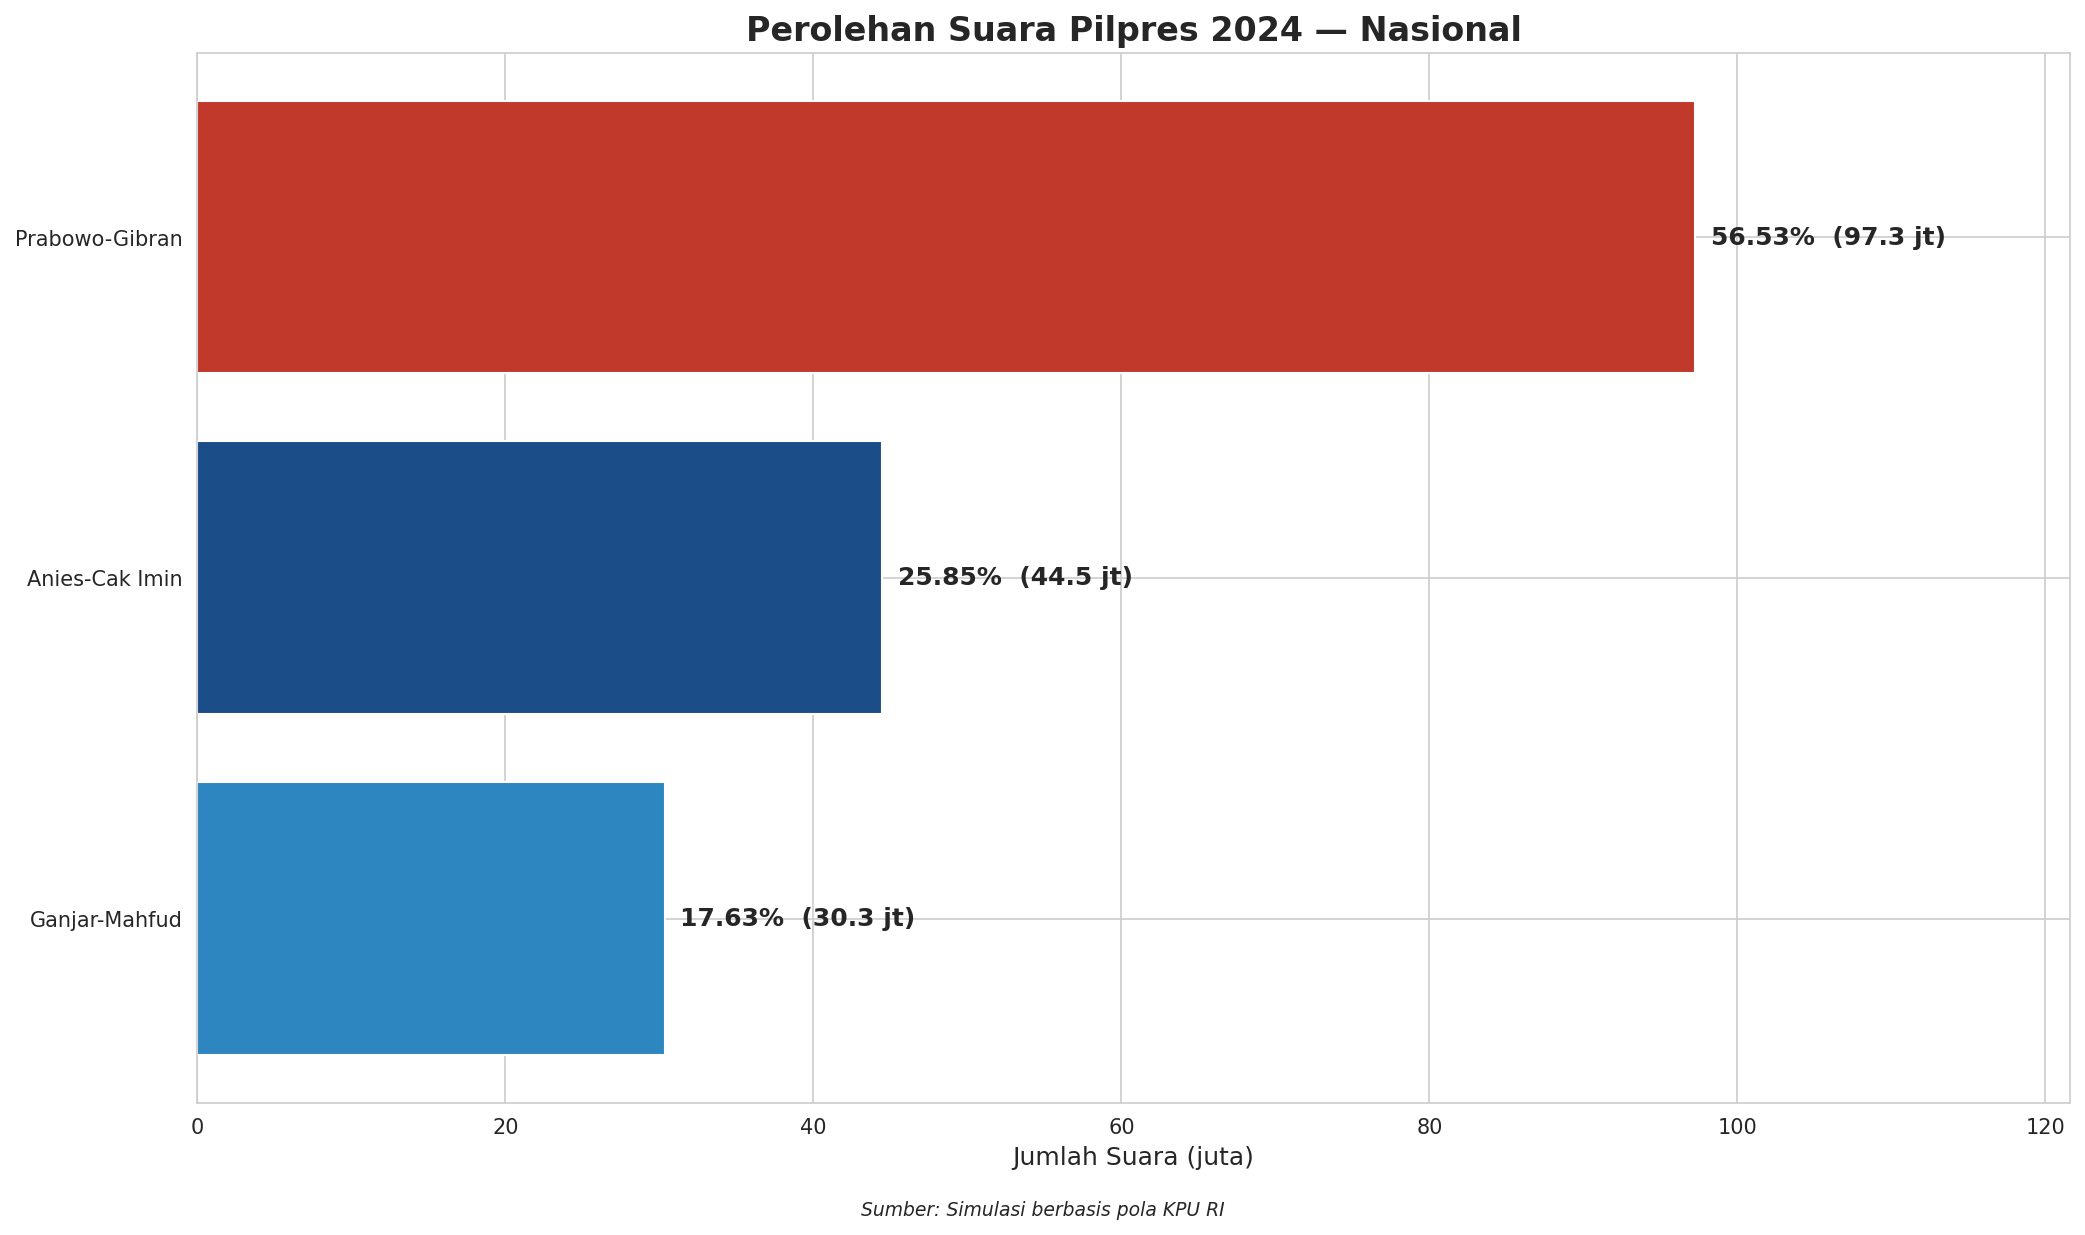

In [4]:
pilpres_nas = (df_pilpres.groupby('paslon')['jumlah_suara'].sum()
                       .sort_values())
total = pilpres_nas.sum()
persen = pilpres_nas / total * 100

fig, ax = plt.subplots(figsize=(14, 8))
warna = [WARNA_PASLON[p] for p in pilpres_nas.index]
bars = ax.barh(pilpres_nas.index, pilpres_nas.values/1e6, color=warna, edgecolor='white')
for bar, pct, jml in zip(bars, persen.values, pilpres_nas.values):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            f'{pct:.2f}%  ({jml/1e6:.1f} jt)', va='center', fontsize=12, fontweight='bold')
ax.set_xlabel('Jumlah Suara (juta)', fontsize=12)
ax.set_title('Perolehan Suara Pilpres 2024 — Nasional')
ax.set_xlim(0, max(pilpres_nas.values/1e6)*1.25)
plt.figtext(0.5, -0.02, 'Sumber: Simulasi berbasis pola KPU RI',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()


## 4. Analisis Partai — Suara Nasional (Pileg 2024)

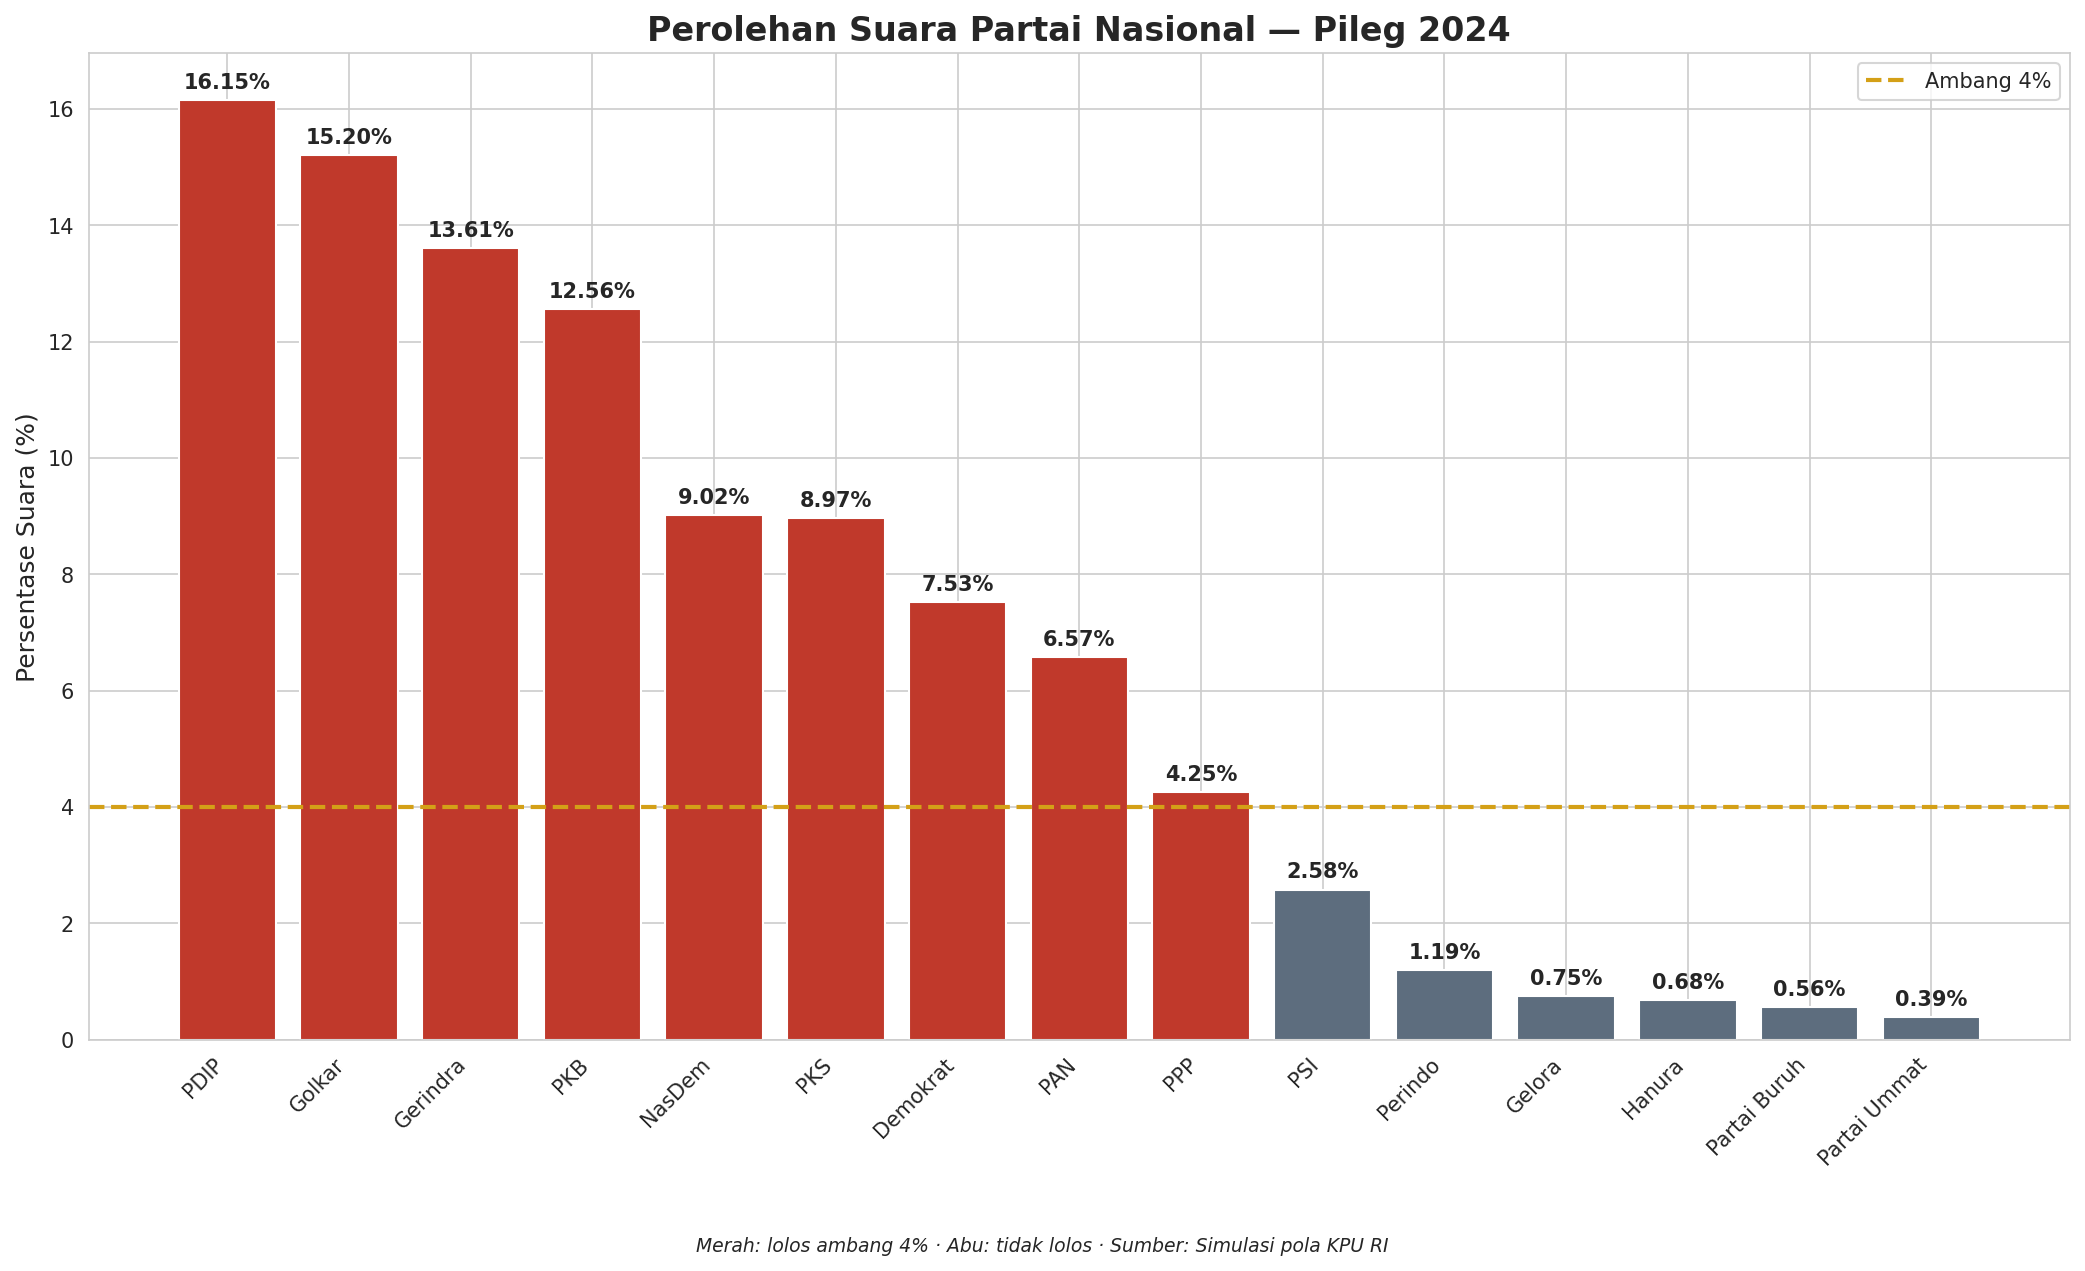

Lolos threshold: ['PDIP', 'Golkar', 'Gerindra', 'PKB', 'NasDem', 'PKS', 'Demokrat', 'PAN', 'PPP']


In [5]:
partai_nas = (df_partai.groupby('partai')['jumlah_suara'].sum()
                     .sort_values(ascending=False))
total_partai = partai_nas.sum()
pct_partai = partai_nas / total_partai * 100
lolos = pct_partai >= 4.0

fig, ax = plt.subplots(figsize=(14, 8))
warna = [WARNA['merah'] if l else WARNA['abu'] for l in lolos]
bars = ax.bar(pct_partai.index, pct_partai.values, color=warna, edgecolor='white')
ax.axhline(4.0, color=WARNA['emas'], linestyle='--', linewidth=2, label='Ambang 4%')
for bar, v in zip(bars, pct_partai.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Persentase Suara (%)', fontsize=12)
ax.set_title('Perolehan Suara Partai Nasional — Pileg 2024')
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.figtext(0.5, -0.05, 'Merah: lolos ambang 4% · Abu: tidak lolos · Sumber: Simulasi pola KPU RI',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()
print('Lolos threshold:', list(pct_partai[lolos].index))


## 5. Heatmap Partai per Provinsi (8 Partai Utama)

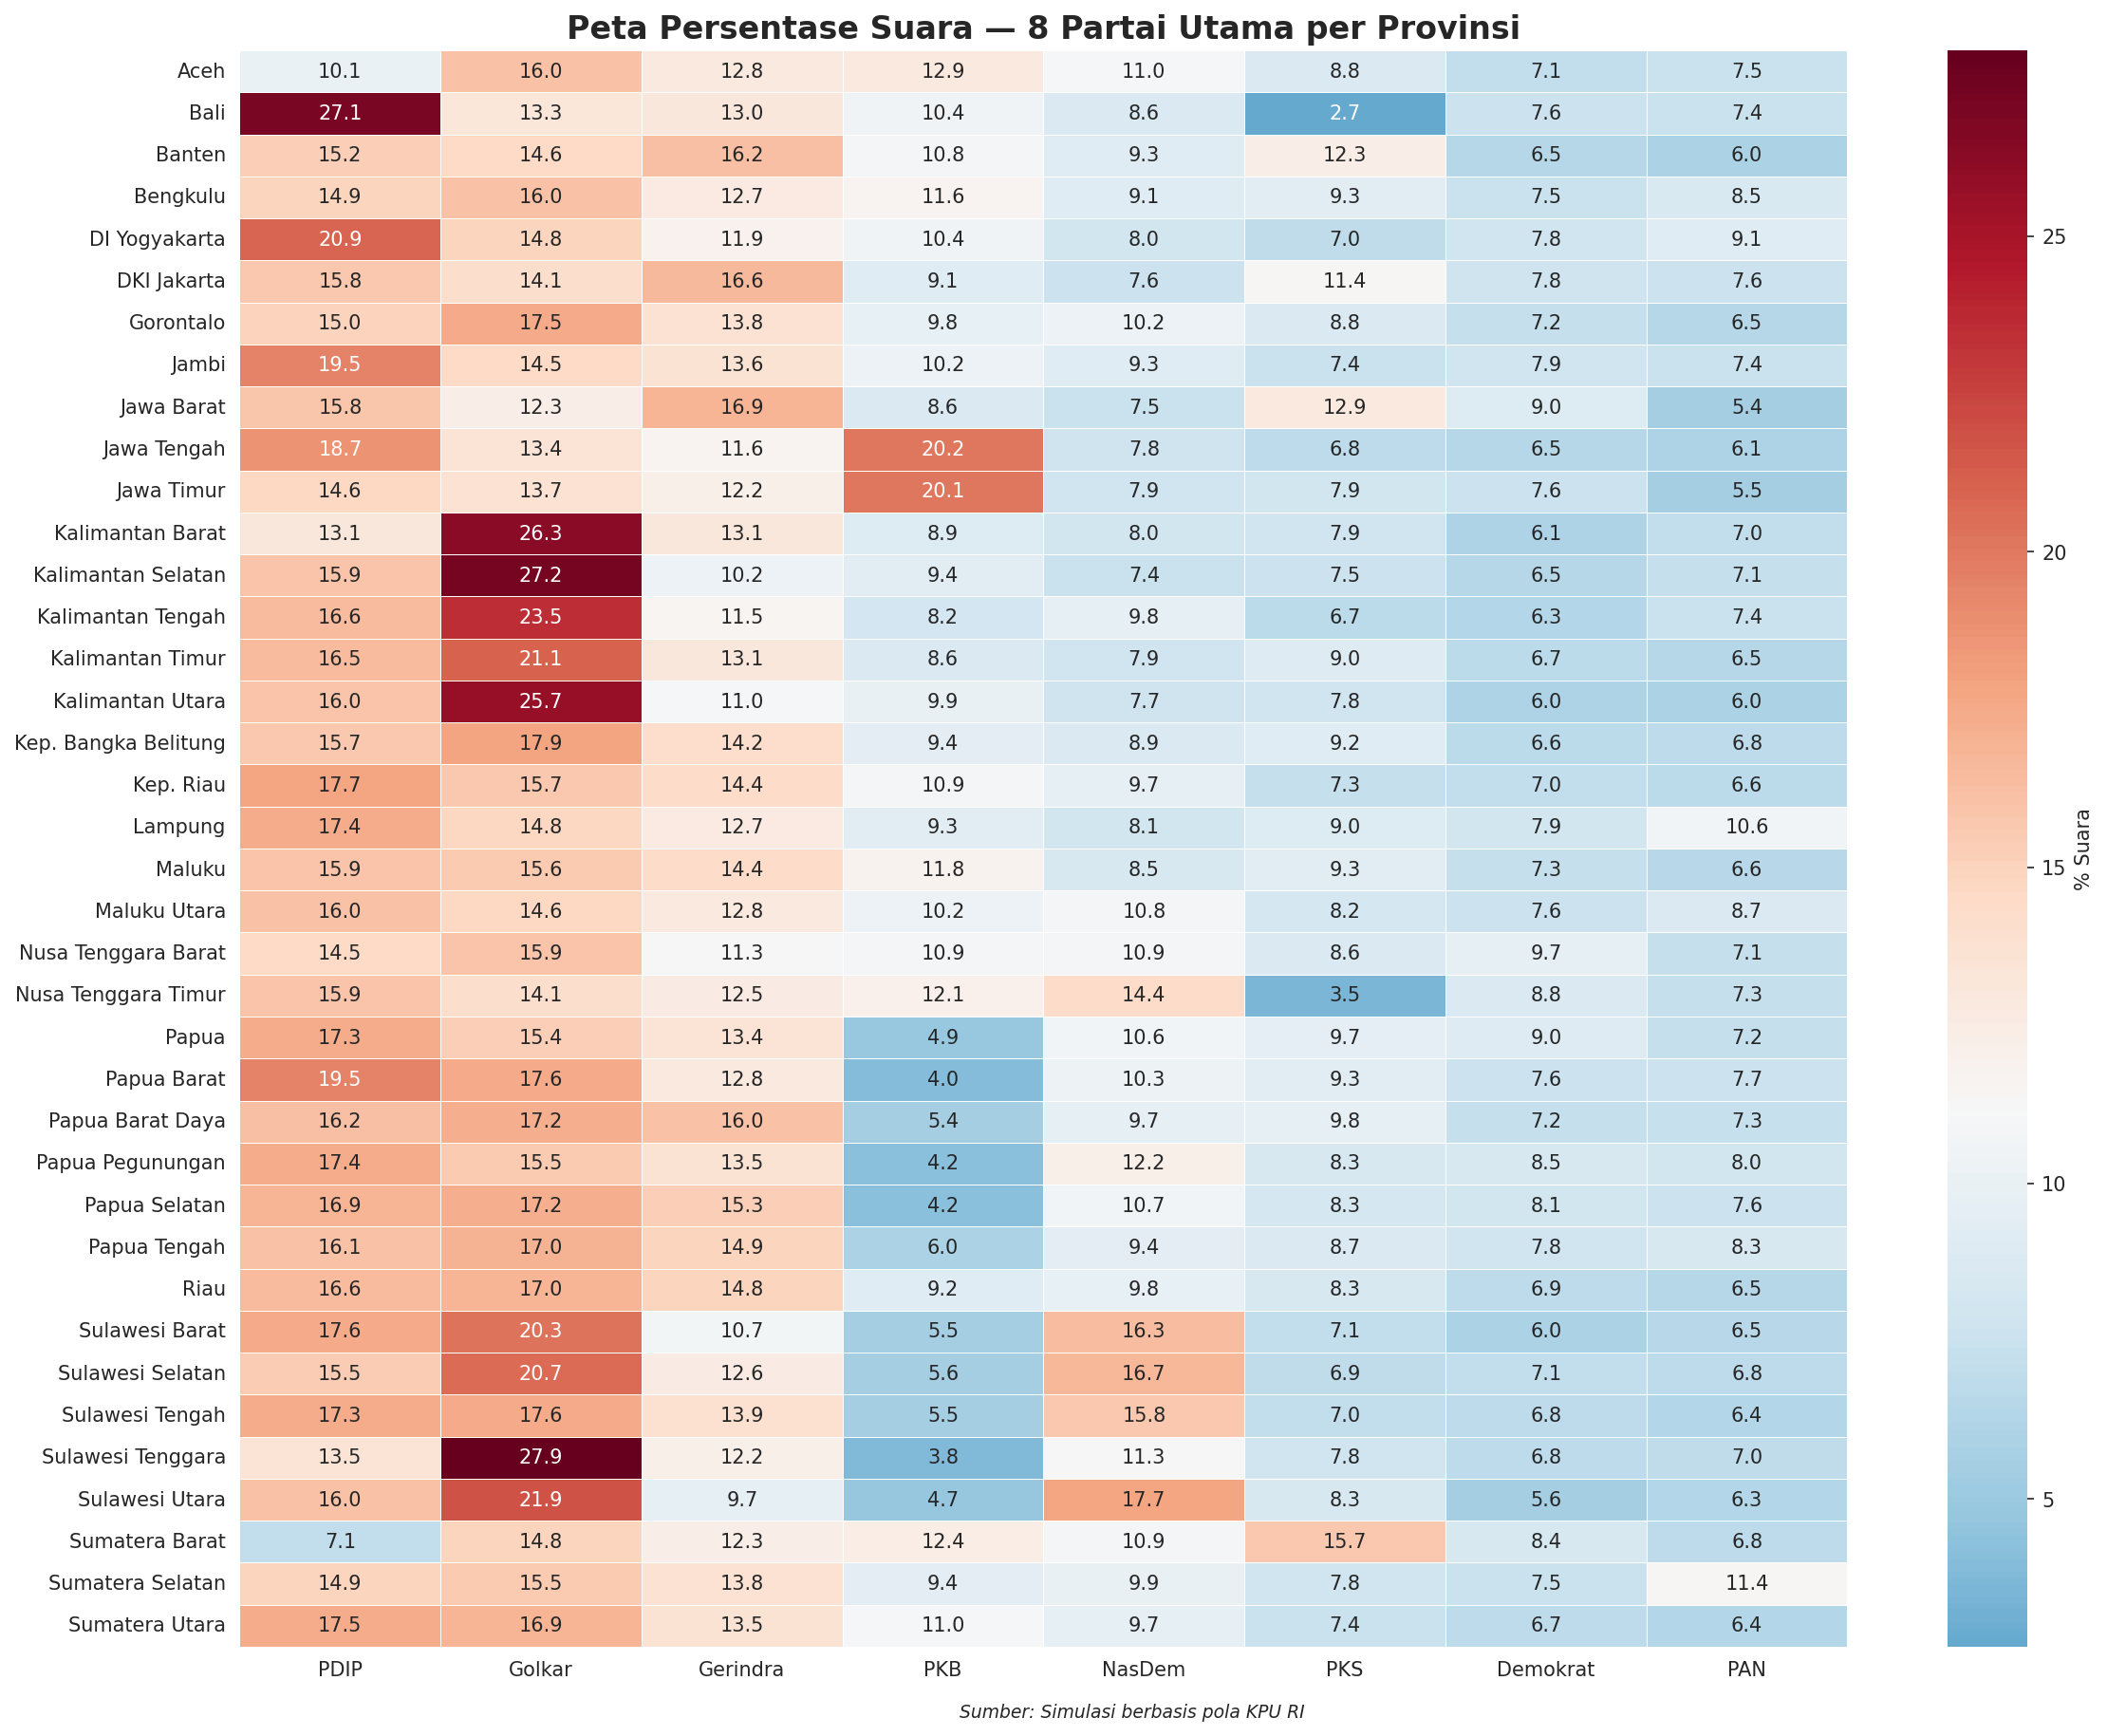

In [6]:
top8 = pct_partai.head(8).index.tolist()
pivot = df_partai[df_partai['partai'].isin(top8)].pivot(
    index='provinsi', columns='partai', values='persentase_suara')
pivot = pivot[top8]

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdBu_r', center=pivot.mean().mean(),
            cbar_kws={'label': '% Suara'}, ax=ax, linewidths=0.4)
ax.set_title('Peta Persentase Suara — 8 Partai Utama per Provinsi')
ax.set_xlabel('')
ax.set_ylabel('')
plt.figtext(0.5, -0.01, 'Sumber: Simulasi berbasis pola KPU RI',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()


## 6. Analisis Partisipasi Pemilih

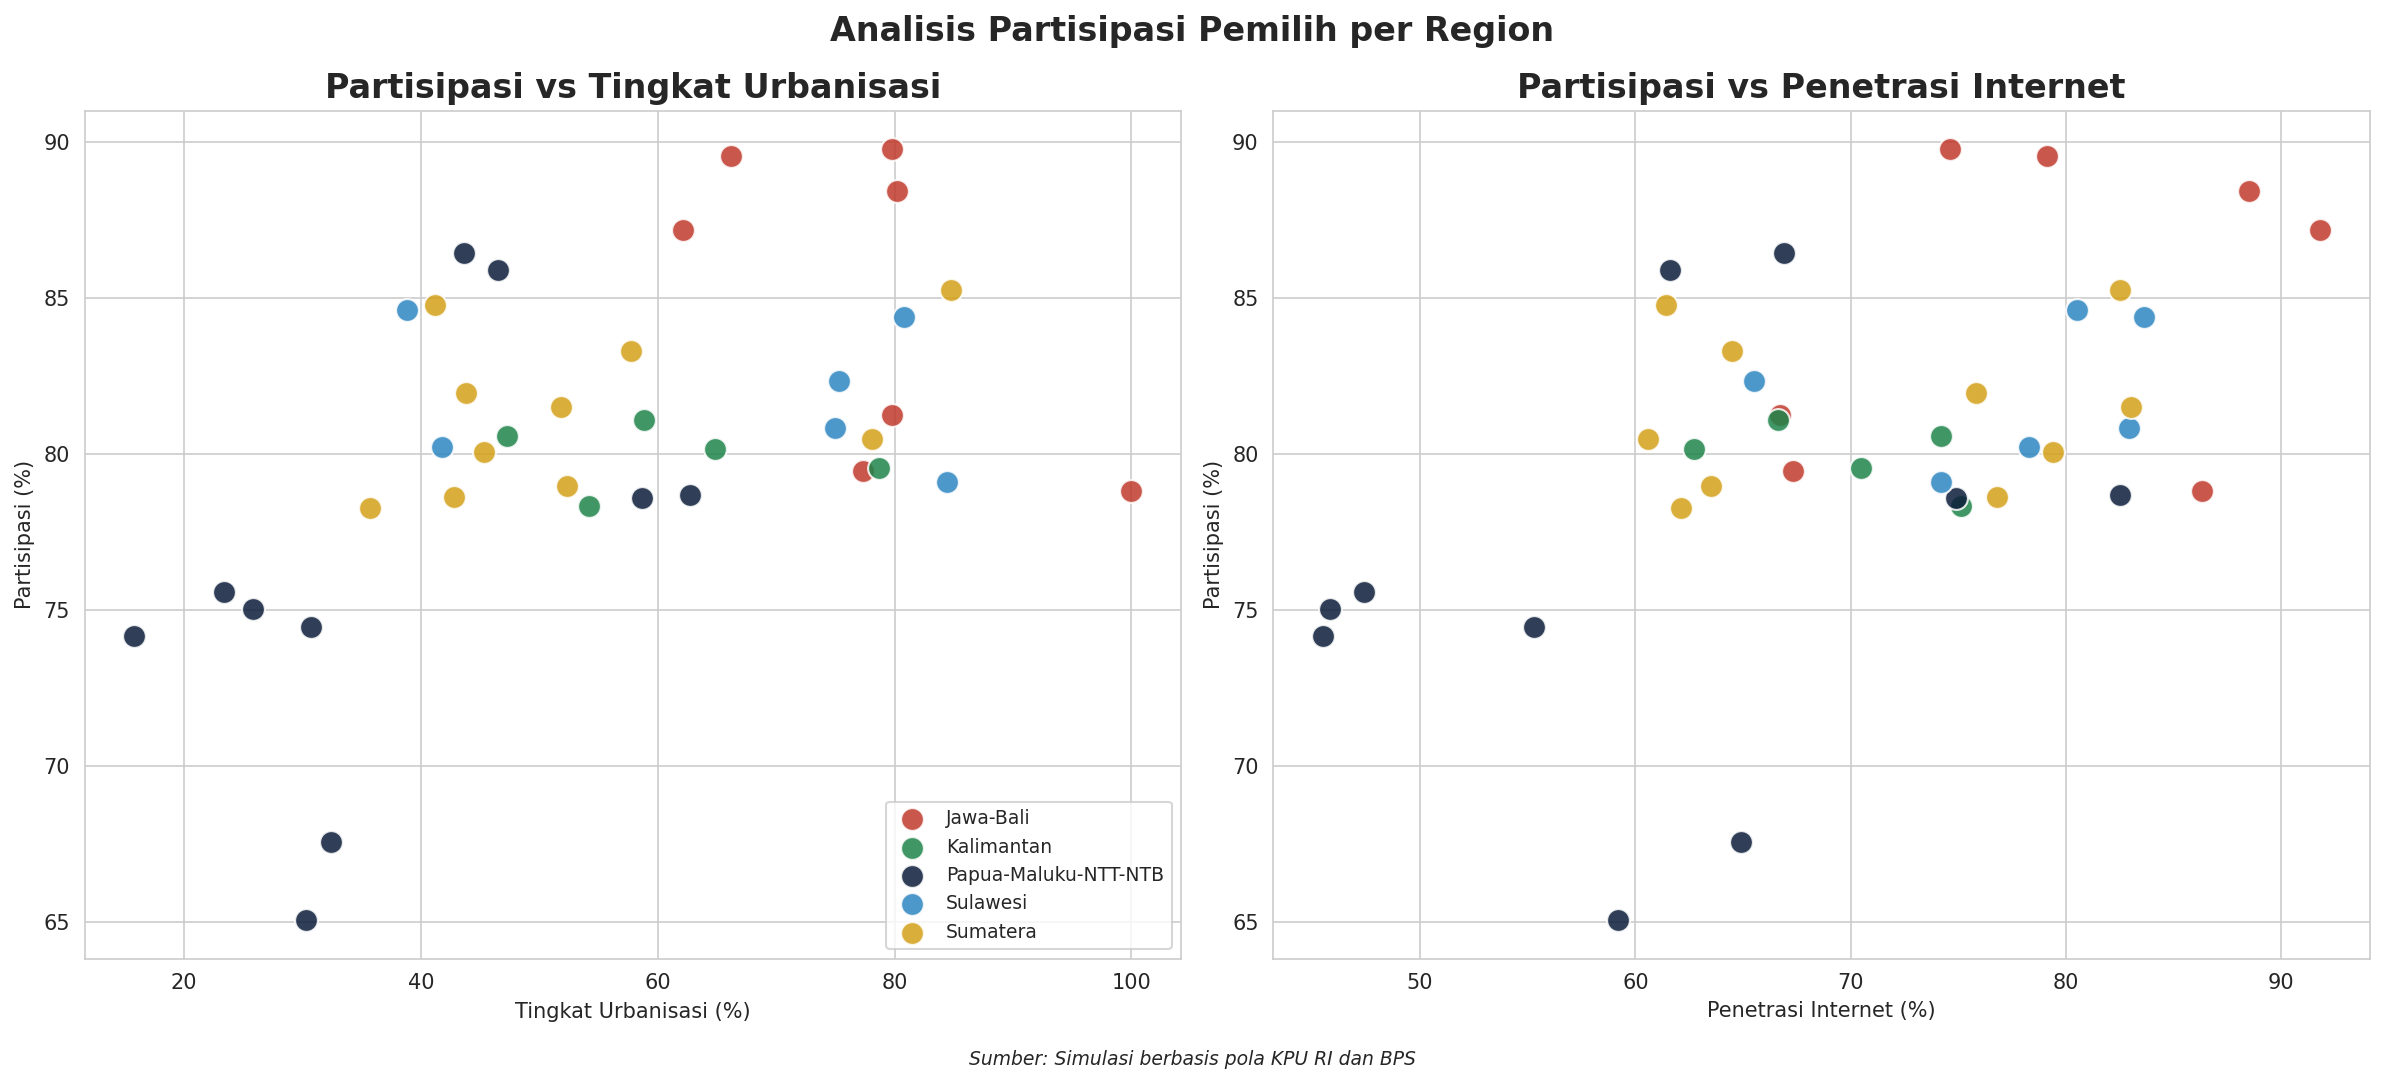

In [7]:
REGION = {
    'Jawa-Bali': ['DKI Jakarta','Jawa Barat','Jawa Tengah','DI Yogyakarta','Jawa Timur','Banten','Bali'],
    'Sumatera': ['Aceh','Sumatera Utara','Sumatera Barat','Riau','Jambi','Sumatera Selatan',
                 'Bengkulu','Lampung','Kep. Bangka Belitung','Kep. Riau'],
    'Kalimantan': ['Kalimantan Barat','Kalimantan Tengah','Kalimantan Selatan',
                   'Kalimantan Timur','Kalimantan Utara'],
    'Sulawesi': ['Sulawesi Utara','Sulawesi Tengah','Sulawesi Selatan','Sulawesi Tenggara',
                 'Gorontalo','Sulawesi Barat'],
    'Papua-Maluku-NTT-NTB': ['Nusa Tenggara Barat','Nusa Tenggara Timur','Maluku','Maluku Utara',
                             'Papua','Papua Barat','Papua Selatan','Papua Tengah',
                             'Papua Pegunungan','Papua Barat Daya'],
}
def region_of(prov):
    for r, provs in REGION.items():
        if prov in provs: return r
    return 'Lain'

df_demo['region'] = df_demo['provinsi'].apply(region_of)
warna_region = {'Jawa-Bali':WARNA['merah'], 'Sumatera':WARNA['emas'],
                'Kalimantan':WARNA['hijau'], 'Sulawesi':WARNA['biru'],
                'Papua-Maluku-NTT-NTB':WARNA['navy']}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, x, xlabel in [(axes[0],'urbanisasi_pct','Tingkat Urbanisasi (%)'),
                       (axes[1],'penetrasi_internet_pct','Penetrasi Internet (%)')]:
    for r, grp in df_demo.groupby('region'):
        ax.scatter(grp[x], grp['tingkat_partisipasi']*100, s=120,
                   color=warna_region.get(r,'gray'), label=r, alpha=0.85, edgecolor='white')
    ax.set_xlabel(xlabel); ax.set_ylabel('Partisipasi (%)')
    ax.set_title(f'Partisipasi vs {xlabel.split(" (")[0]}')
axes[0].legend(loc='lower right', fontsize=9)
plt.suptitle('Analisis Partisipasi Pemilih per Region', fontsize=16, fontweight='bold')
plt.figtext(0.5, -0.02, 'Sumber: Simulasi berbasis pola KPU RI dan BPS',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()


## 7. Korelasi Faktor Sosiodemografi

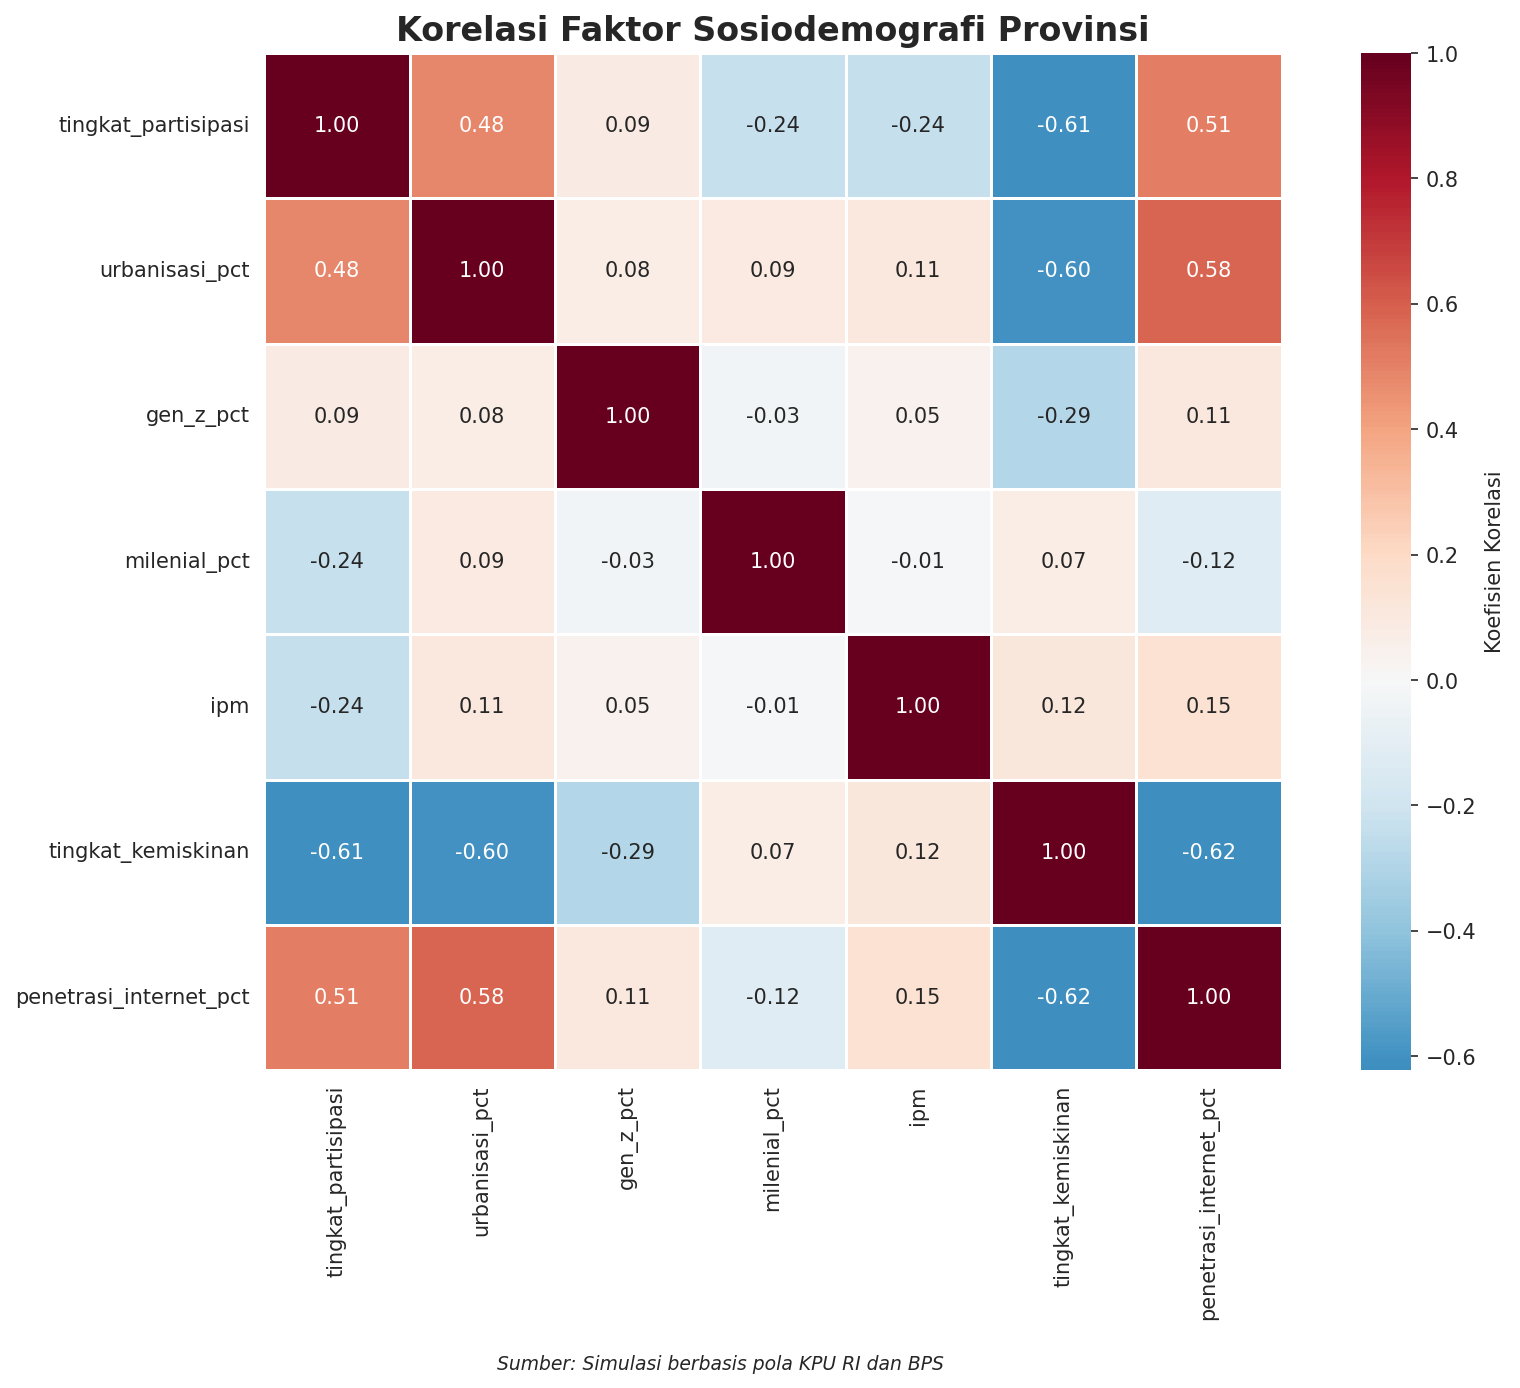

In [8]:
fitur_korr = ['tingkat_partisipasi','urbanisasi_pct','gen_z_pct','milenial_pct',
              'ipm','tingkat_kemiskinan','penetrasi_internet_pct']
korr = df_demo[fitur_korr].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(korr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'label':'Koefisien Korelasi'}, ax=ax, linewidths=0.5)
ax.set_title('Korelasi Faktor Sosiodemografi Provinsi')
plt.figtext(0.5, -0.02, 'Sumber: Simulasi berbasis pola KPU RI dan BPS',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()


## 8. Analisis Pemilih Muda (Gen Z + Milenial)

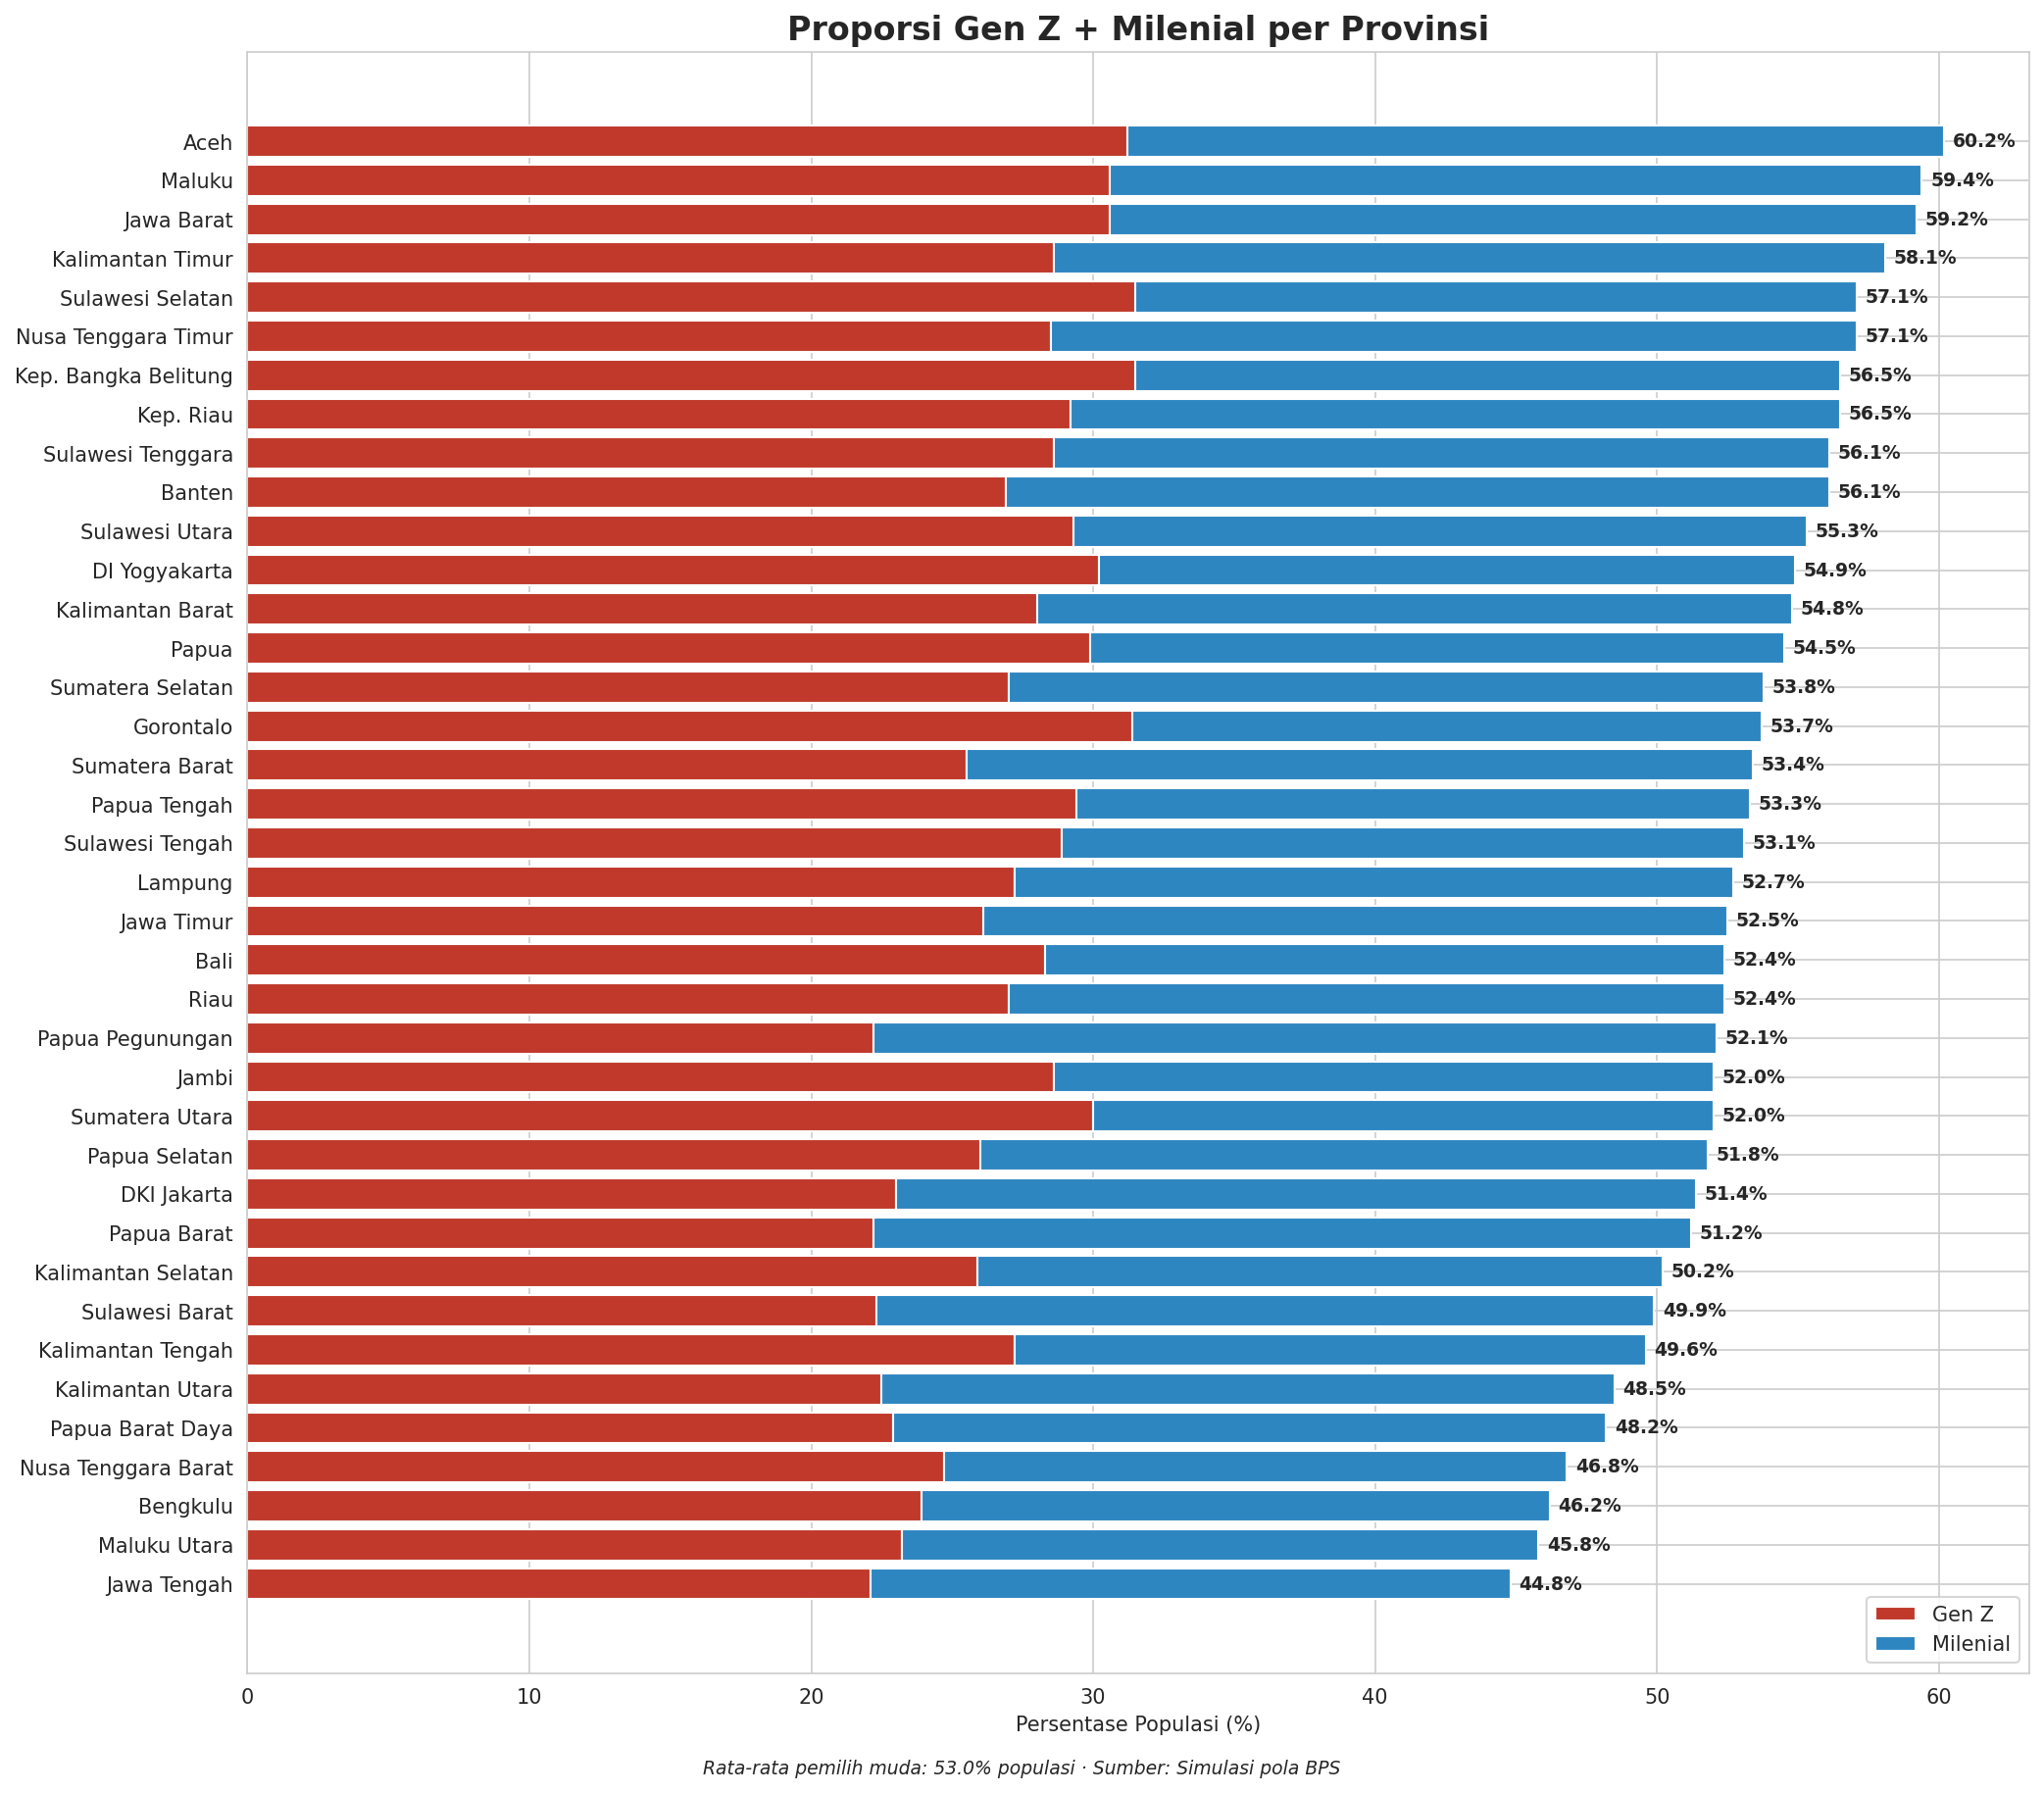

In [9]:
d = df_demo.copy()
d['muda_pct'] = d['gen_z_pct'] + d['milenial_pct']
d = d.sort_values('muda_pct', ascending=True)

fig, ax = plt.subplots(figsize=(14, 12))
ax.barh(d['provinsi'], d['gen_z_pct'], color=WARNA['merah'], label='Gen Z')
ax.barh(d['provinsi'], d['milenial_pct'], left=d['gen_z_pct'],
        color=WARNA['biru'], label='Milenial')
for i, (_, row) in enumerate(d.iterrows()):
    ax.text(row['muda_pct']+0.3, i, f"{row['muda_pct']:.1f}%",
            va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Persentase Populasi (%)')
ax.set_title('Proporsi Gen Z + Milenial per Provinsi')
ax.legend(loc='lower right')
plt.figtext(0.5, -0.01,
            'Rata-rata pemilih muda: {:.1f}% populasi · Sumber: Simulasi pola BPS'.format(d['muda_pct'].mean()),
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()


## 9. Analisis Sentimen Publik

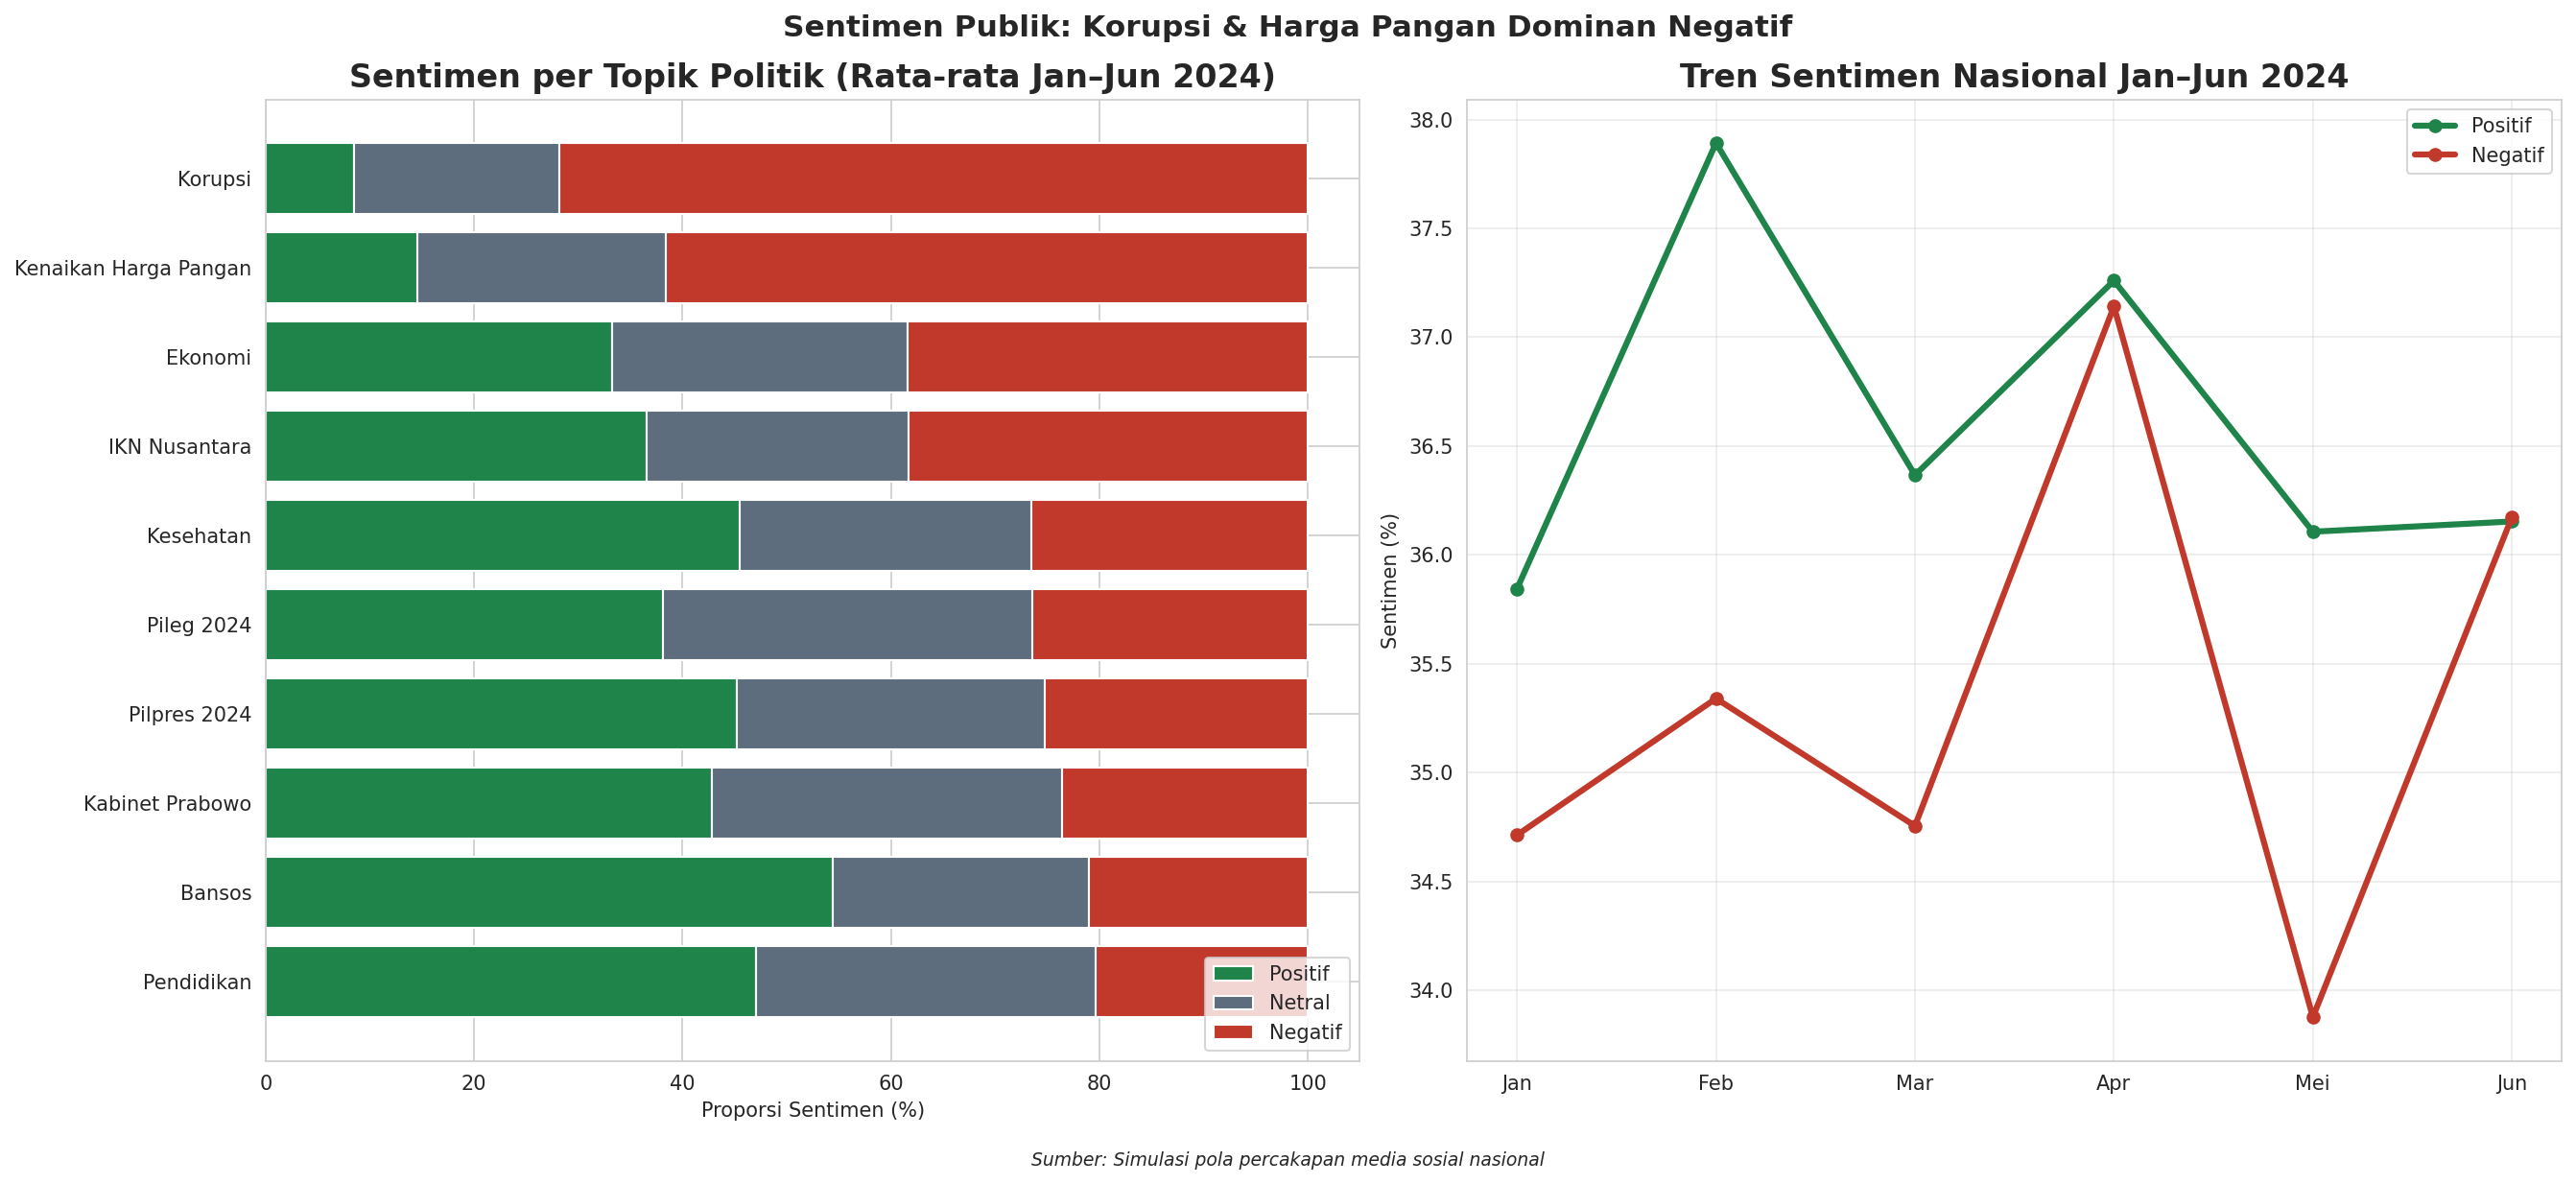

In [10]:
sen_agg = df_sentimen.groupby('topik')[['positif_pct','netral_pct','negatif_pct']].mean()
sen_agg = sen_agg.sort_values('negatif_pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
ax = axes[0]
ax.barh(sen_agg.index, sen_agg['positif_pct'], color=WARNA['hijau'], label='Positif')
ax.barh(sen_agg.index, sen_agg['netral_pct'], left=sen_agg['positif_pct'],
        color=WARNA['abu'], label='Netral')
ax.barh(sen_agg.index, sen_agg['negatif_pct'],
        left=sen_agg['positif_pct']+sen_agg['netral_pct'],
        color=WARNA['merah'], label='Negatif')
ax.set_xlabel('Proporsi Sentimen (%)')
ax.set_title('Sentimen per Topik Politik (Rata-rata Jan–Jun 2024)')
ax.legend(loc='lower right')

ax = axes[1]
tren = df_sentimen.groupby('bulan_num')[['positif_pct','negatif_pct']].mean()
bulan_lbl = ['Jan','Feb','Mar','Apr','Mei','Jun']
ax.plot(bulan_lbl, tren['positif_pct'], marker='o', linewidth=3,
        color=WARNA['hijau'], label='Positif')
ax.plot(bulan_lbl, tren['negatif_pct'], marker='o', linewidth=3,
        color=WARNA['merah'], label='Negatif')
ax.set_ylabel('Sentimen (%)')
ax.set_title('Tren Sentimen Nasional Jan–Jun 2024')
ax.legend()
ax.grid(True, alpha=0.4)

plt.suptitle('Sentimen Publik: Korupsi & Harga Pangan Dominan Negatif', fontsize=15, fontweight='bold')
plt.figtext(0.5, -0.02, 'Sumber: Simulasi pola percakapan media sosial nasional',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()


## 10. K-Means Clustering Provinsi (K=4)

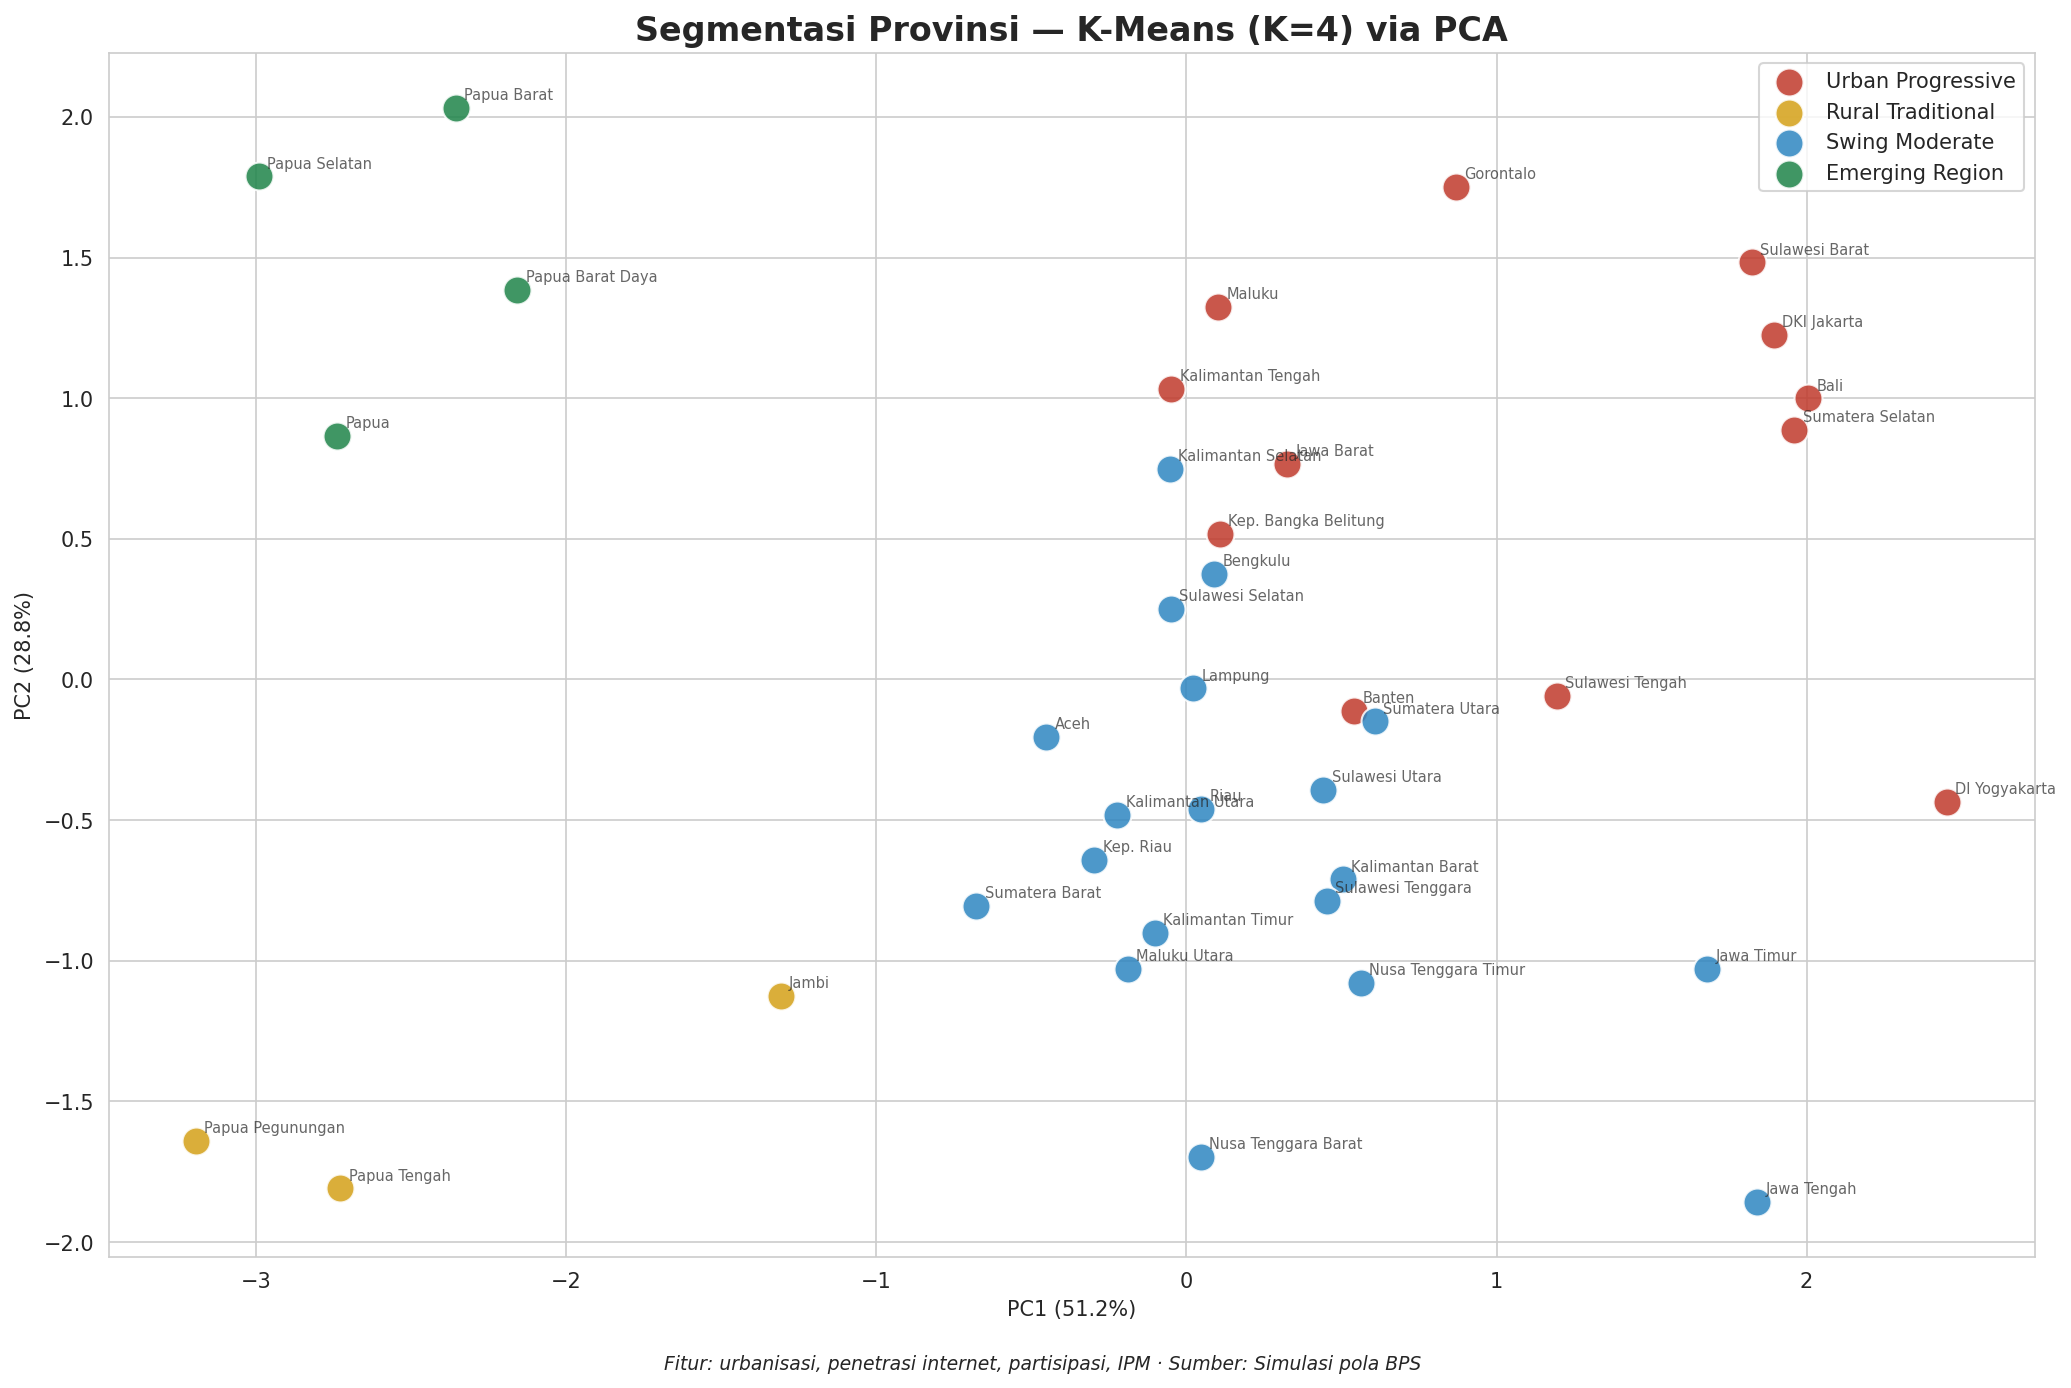

,provinsi,cluster_nama
37,Papua Barat Daya,Emerging Region
34,Papua Selatan,Emerging Region
33,Papua Barat,Emerging Region
32,Papua,Emerging Region
35,Papua Tengah,Rural Traditional
4,Jambi,Rural Traditional
36,Papua Pegunungan,Rural Traditional
31,Maluku Utara,Swing Moderate
27,Sulawesi Tenggara,Swing Moderate
26,Sulawesi Selatan,Swing Moderate


In [11]:
fitur_cluster = ['urbanisasi_pct','penetrasi_internet_pct','tingkat_partisipasi','ipm']
X = df_demo[fitur_cluster].copy()
X['tingkat_partisipasi'] *= 100
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

km = KMeans(n_clusters=4, random_state=42, n_init=20)
label = km.fit_predict(Xs)

pca = PCA(n_components=2, random_state=42)
Xp = pca.fit_transform(Xs)

profil = pd.DataFrame(Xs, columns=fitur_cluster)
profil['cluster'] = label
mean_profil = profil.groupby('cluster').mean()

# heuristik nama cluster berdasarkan profil rata-rata
nama_cluster = {}
for c in mean_profil.index:
    urban, internet, part, ipm = mean_profil.loc[c].values
    if urban > 0.5 and internet > 0.3:
        nama_cluster[c] = 'Urban Progressive'
    elif ipm < -0.5 or part < -0.5:
        nama_cluster[c] = 'Emerging Region'
    elif urban < -0.2 and part > 0.3:
        nama_cluster[c] = 'Rural Traditional'
    else:
        nama_cluster[c] = 'Swing Moderate'
# jamin 4 label unik
used = list(nama_cluster.values())
pool = ['Urban Progressive','Rural Traditional','Swing Moderate','Emerging Region']
for c in nama_cluster:
    if used.count(nama_cluster[c]) > 1:
        for alt in pool:
            if alt not in used:
                nama_cluster[c] = alt
                used = list(nama_cluster.values())
                break

df_demo['cluster'] = label
df_demo['cluster_nama'] = df_demo['cluster'].map(nama_cluster)

warna_cluster = {'Urban Progressive':WARNA['merah'], 'Rural Traditional':WARNA['emas'],
                 'Swing Moderate':WARNA['biru'], 'Emerging Region':WARNA['hijau']}

fig, ax = plt.subplots(figsize=(14, 9))
for nama, warna in warna_cluster.items():
    mask = df_demo['cluster_nama'] == nama
    ax.scatter(Xp[mask,0], Xp[mask,1], s=180, color=warna, label=nama,
               edgecolor='white', alpha=0.85)
for i, prov in enumerate(df_demo['provinsi']):
    ax.annotate(prov, (Xp[i,0], Xp[i,1]), fontsize=7, alpha=0.7,
                xytext=(4,4), textcoords='offset points')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Segmentasi Provinsi — K-Means (K=4) via PCA')
ax.legend(loc='best')
plt.figtext(0.5, -0.02, 'Fitur: urbanisasi, penetrasi internet, partisipasi, IPM · Sumber: Simulasi pola BPS',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()

df_demo[['provinsi','cluster_nama']].sort_values('cluster_nama')


## 11. Tren Historis Partai (2009–2024)

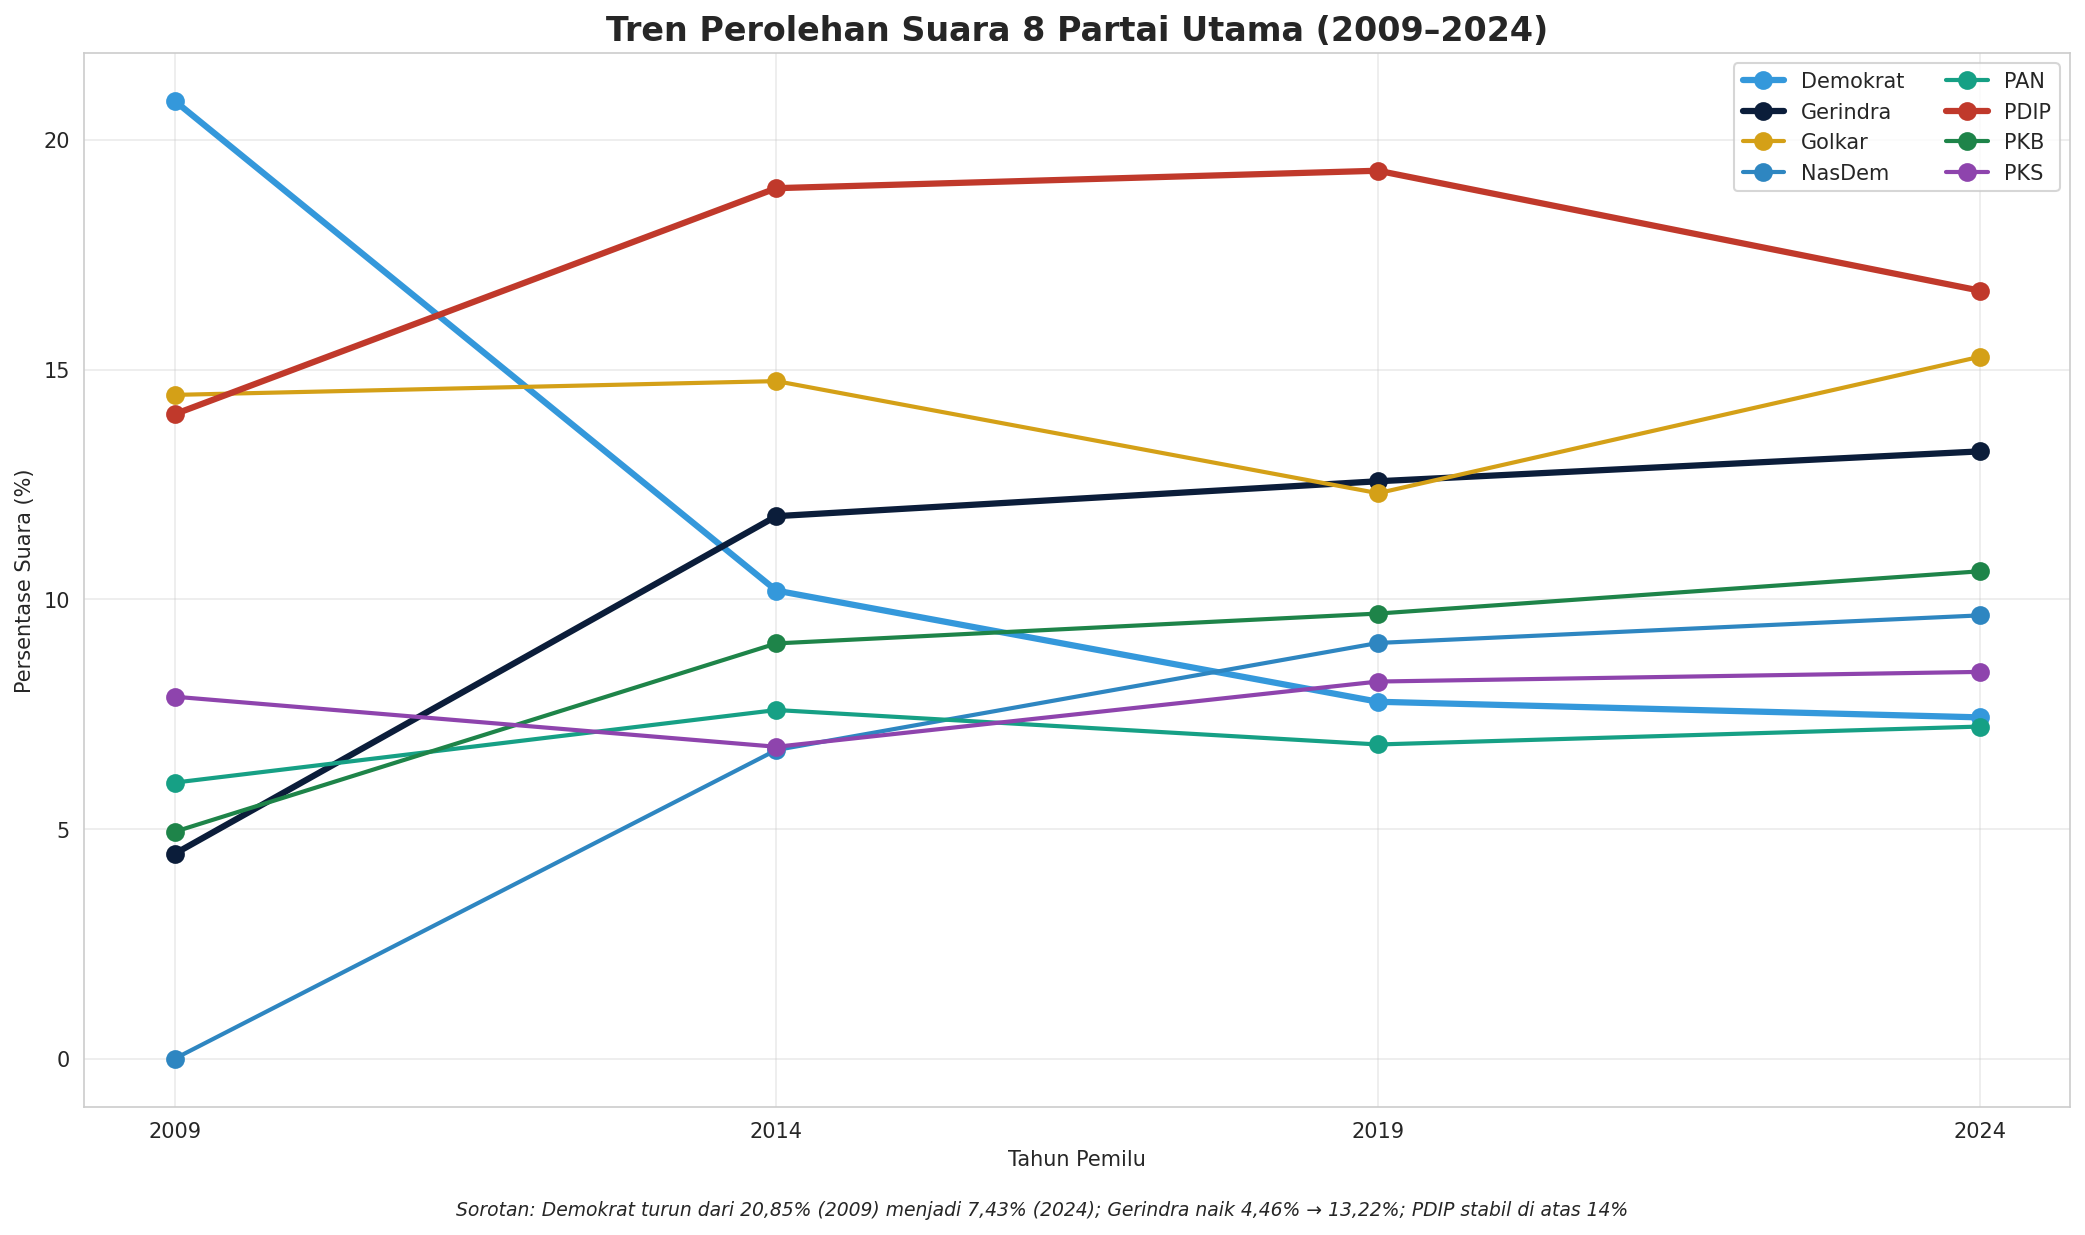

In [12]:
warna_hist = {'PDIP':WARNA['merah'], 'Golkar':WARNA['emas'], 'Gerindra':WARNA['navy'],
              'PKB':WARNA['hijau'], 'NasDem':WARNA['biru'], 'PKS':'#8E44AD',
              'Demokrat':'#3498DB', 'PAN':'#16A085'}
fig, ax = plt.subplots(figsize=(14, 8))
for partai, grp in df_historis.groupby('partai'):
    grp = grp.sort_values('tahun_pemilu')
    style = '-o'
    lw = 3 if partai in ['PDIP','Gerindra','Demokrat'] else 2
    ax.plot(grp['tahun_pemilu'], grp['persentase_suara'], style,
            color=warna_hist.get(partai,'gray'), label=partai, linewidth=lw, markersize=8)
ax.set_xticks([2009,2014,2019,2024])
ax.set_xlabel('Tahun Pemilu'); ax.set_ylabel('Persentase Suara (%)')
ax.set_title('Tren Perolehan Suara 8 Partai Utama (2009–2024)')
ax.legend(loc='upper right', ncol=2)
ax.grid(True, alpha=0.4)
plt.figtext(0.5, -0.02,
            'Sorotan: Demokrat turun dari 20,85% (2009) menjadi 7,43% (2024); Gerindra naik 4,46% → 13,22%; PDIP stabil di atas 14%',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()


## 12. Model Prediktif — Feature Importance

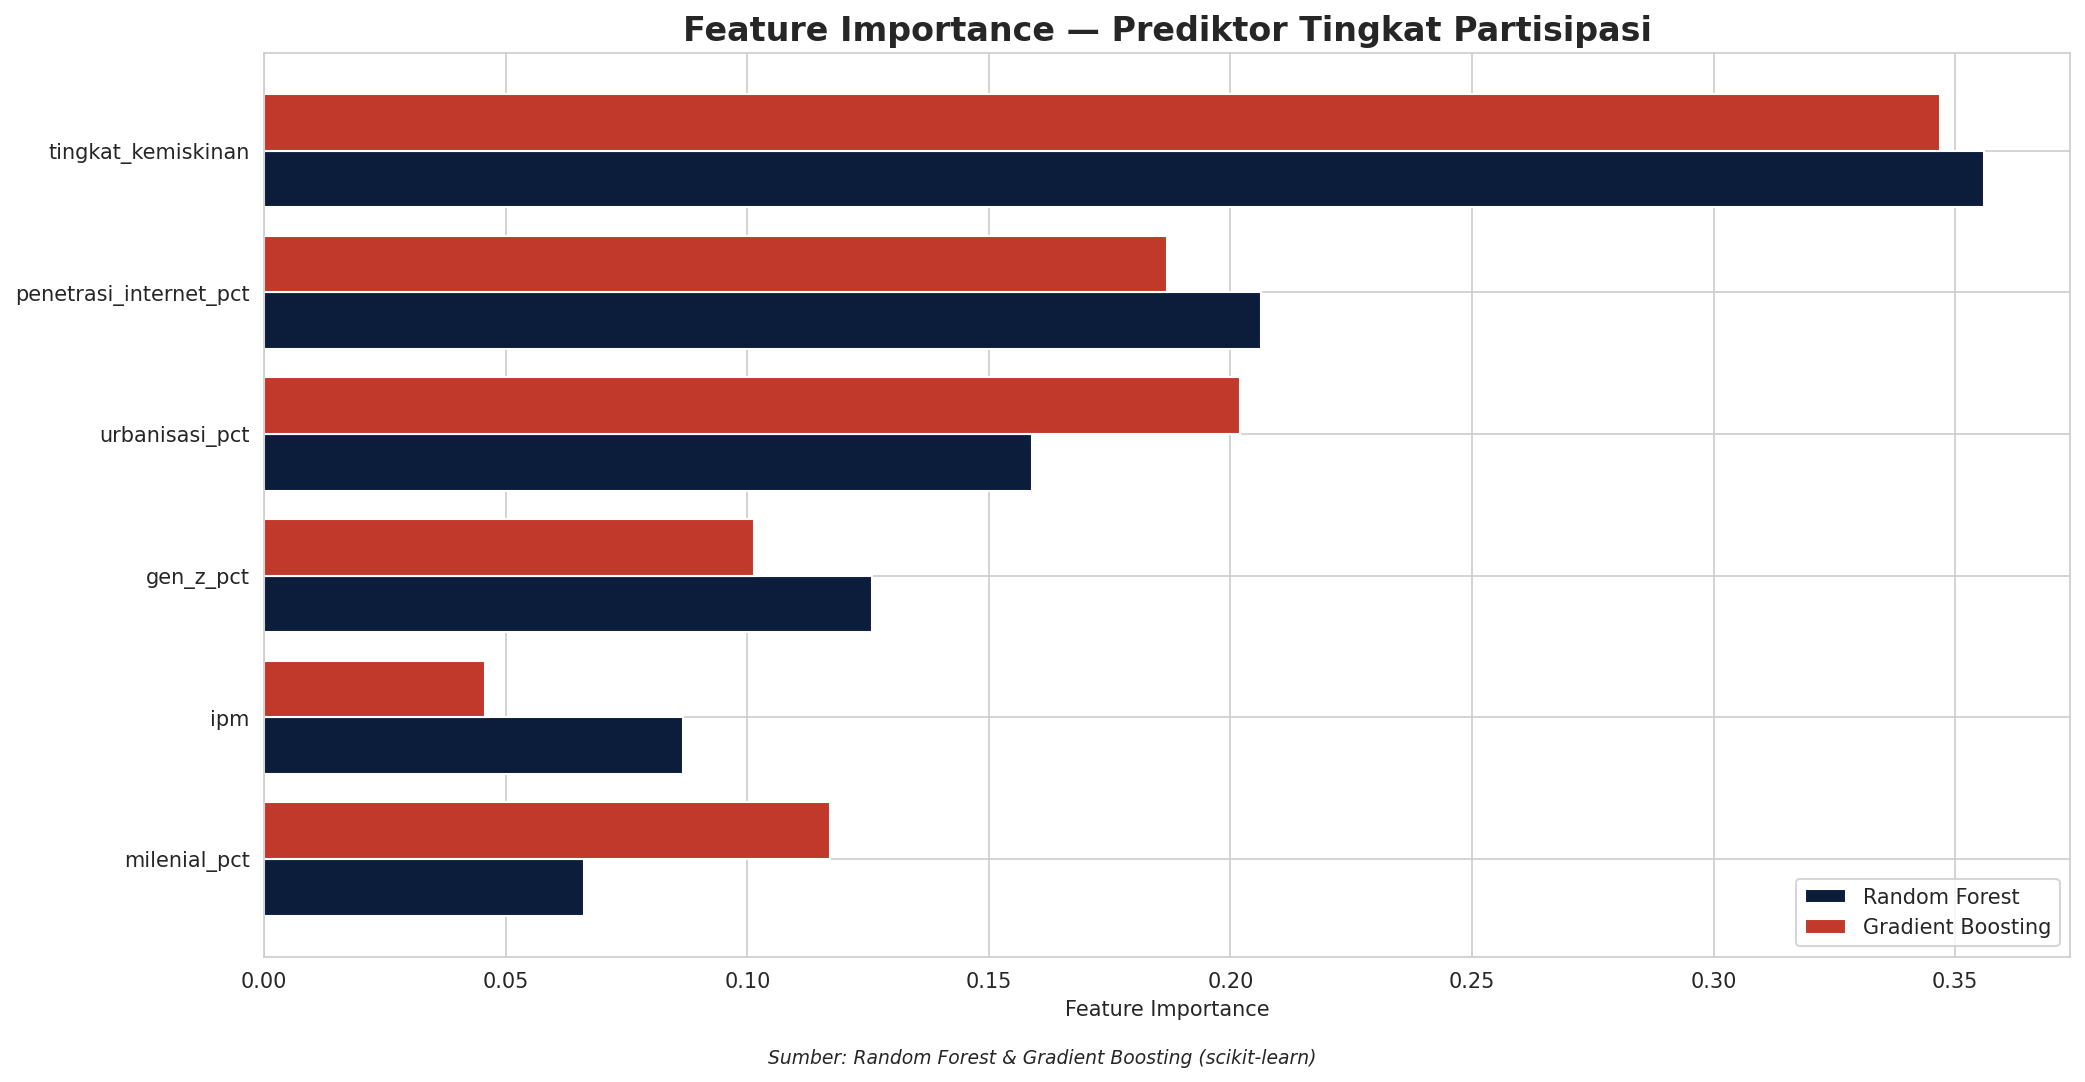

,RandomForest,GradientBoosting
fitur,,
milenial_pct,0.066116,0.117114
ipm,0.086661,0.045736
gen_z_pct,0.125890,0.101287
urbanisasi_pct,0.158972,0.201947
penetrasi_internet_pct,0.206375,0.186968
tingkat_kemiskinan,0.355986,0.346948


In [13]:
d = df_demo.copy()
fitur_ml = ['urbanisasi_pct','gen_z_pct','milenial_pct','ipm',
            'tingkat_kemiskinan','penetrasi_internet_pct']
X = d[fitur_ml].values
y = (d['tingkat_partisipasi']*100).values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_train, y_train)
gb = GradientBoostingRegressor(n_estimators=300, random_state=42).fit(X_train, y_train)

imp = pd.DataFrame({
    'fitur': fitur_ml,
    'RandomForest': rf.feature_importances_,
    'GradientBoosting': gb.feature_importances_,
}).set_index('fitur').sort_values('RandomForest')

fig, ax = plt.subplots(figsize=(14, 7))
y_pos = np.arange(len(imp))
ax.barh(y_pos-0.2, imp['RandomForest'], height=0.4, color=WARNA['navy'], label='Random Forest')
ax.barh(y_pos+0.2, imp['GradientBoosting'], height=0.4, color=WARNA['merah'], label='Gradient Boosting')
ax.set_yticks(y_pos); ax.set_yticklabels(imp.index)
ax.set_xlabel('Feature Importance')
ax.set_title('Feature Importance — Prediktor Tingkat Partisipasi')
ax.legend()
plt.figtext(0.5, -0.02, 'Sumber: Random Forest & Gradient Boosting (scikit-learn)',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()
imp


## 13. Model Prediktif — Akurasi (Actual vs Predicted)

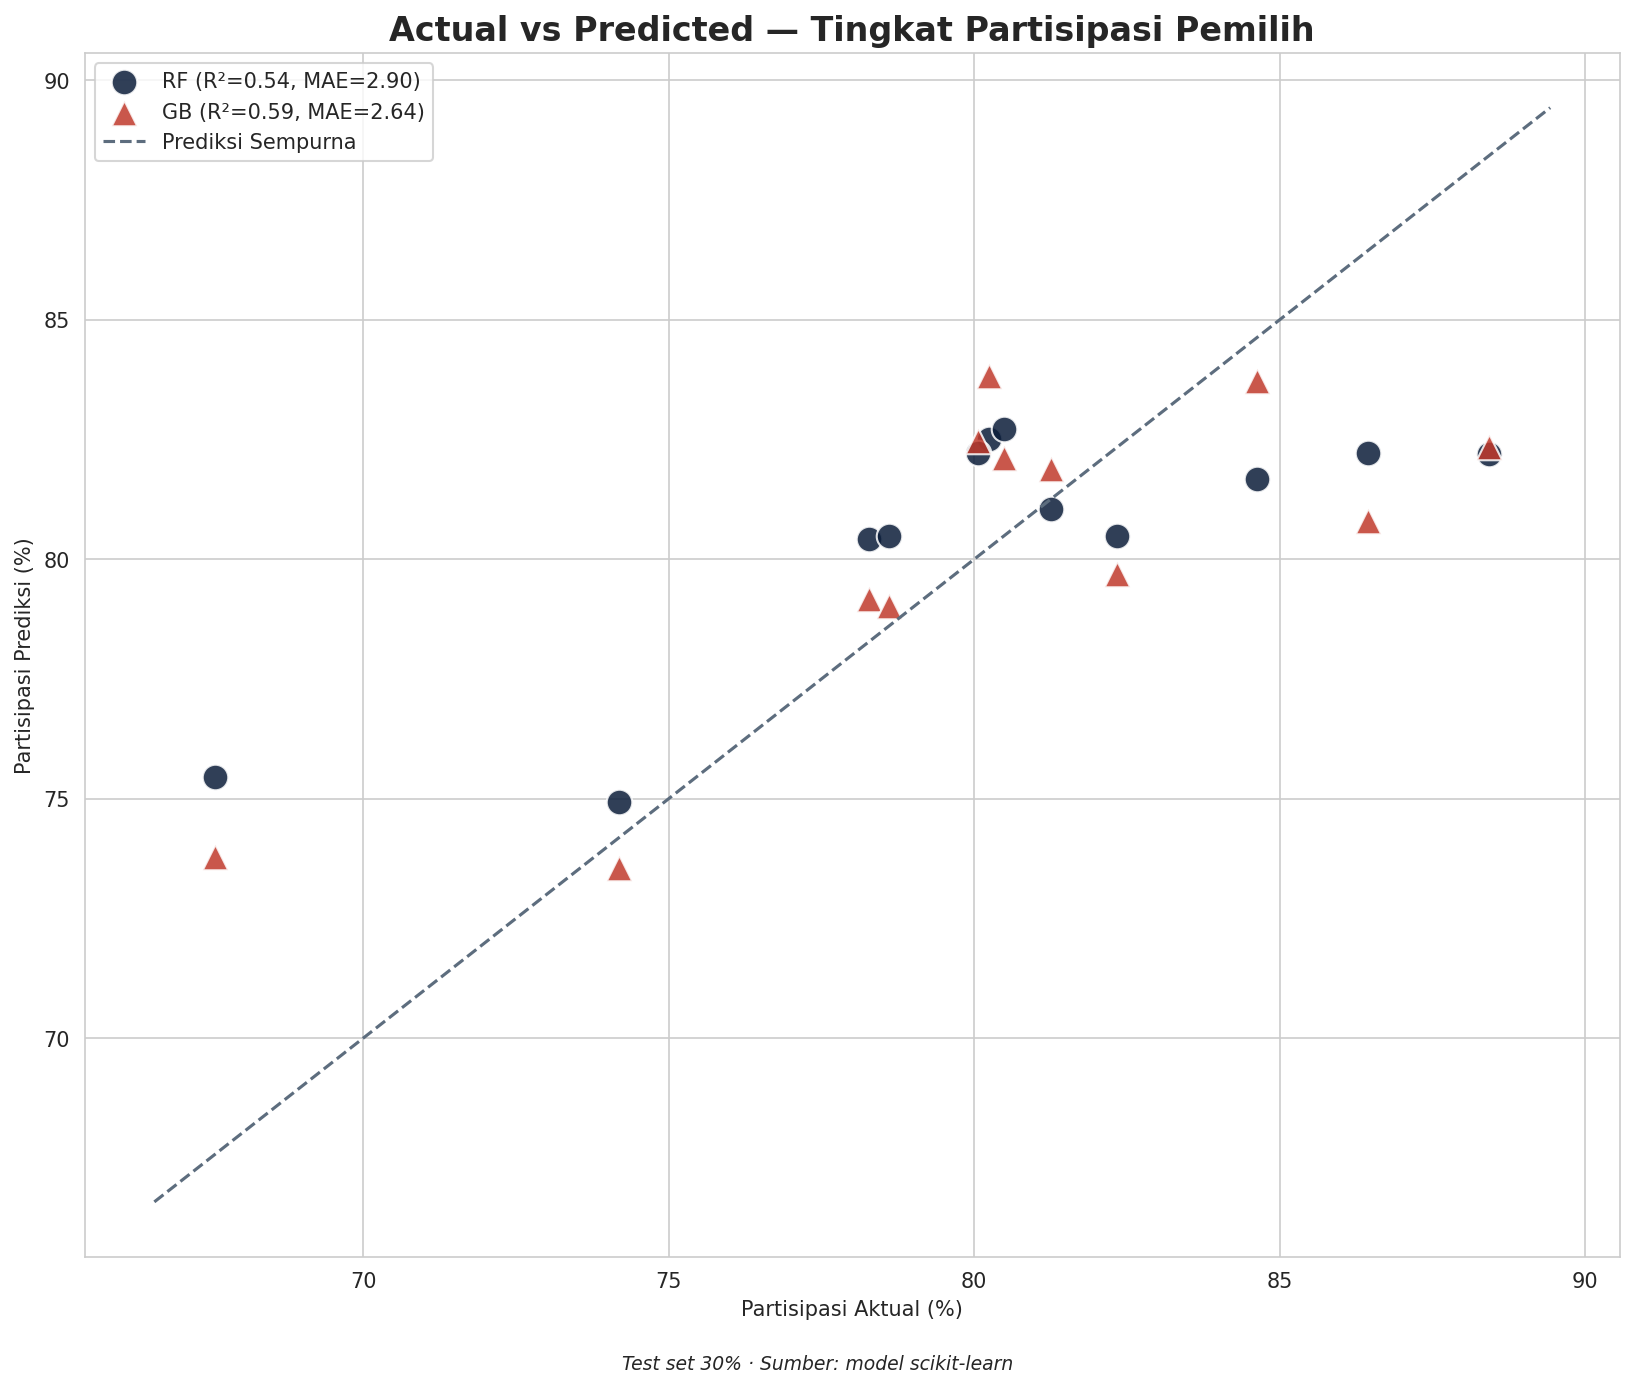

{'r2_rf': 0.537, 'mae_rf': 2.899, 'r2_gb': 0.585, 'mae_gb': 2.641, 'total_suara_pilpres': 172089686, 'partisipasi_rata2': np.float64(80.55), 'lolos_threshold': 9, 'jumlah_provinsi': 38}


In [14]:
pred_rf = rf.predict(X_test); pred_gb = gb.predict(X_test)
r2_rf = r2_score(y_test, pred_rf); mae_rf = mean_absolute_error(y_test, pred_rf)
r2_gb = r2_score(y_test, pred_gb); mae_gb = mean_absolute_error(y_test, pred_gb)

fig, ax = plt.subplots(figsize=(11, 9))
ax.scatter(y_test, pred_rf, s=150, color=WARNA['navy'], label=f'RF (R²={r2_rf:.2f}, MAE={mae_rf:.2f})',
           edgecolor='white', alpha=0.85)
ax.scatter(y_test, pred_gb, s=150, color=WARNA['merah'], label=f'GB (R²={r2_gb:.2f}, MAE={mae_gb:.2f})',
           edgecolor='white', alpha=0.85, marker='^')
lo, hi = min(y_test.min(), pred_rf.min())-1, max(y_test.max(), pred_rf.max())+1
ax.plot([lo,hi],[lo,hi], '--', color=WARNA['abu'], label='Prediksi Sempurna')
ax.set_xlabel('Partisipasi Aktual (%)'); ax.set_ylabel('Partisipasi Prediksi (%)')
ax.set_title('Actual vs Predicted — Tingkat Partisipasi Pemilih')
ax.legend(loc='upper left')
plt.figtext(0.5, -0.02, 'Test set 30% · Sumber: model scikit-learn',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()

metrik = {'r2_rf': round(r2_rf,3), 'mae_rf': round(mae_rf,3),
          'r2_gb': round(r2_gb,3), 'mae_gb': round(mae_gb,3),
          'total_suara_pilpres': int(df_pilpres['jumlah_suara'].sum()),
          'partisipasi_rata2': round(df_demo['tingkat_partisipasi'].mean()*100,2),
          'lolos_threshold': int(lolos.sum()),
          'jumlah_provinsi': int(df_demo['provinsi'].nunique())}
with open('metrik.json','w') as f:
    json.dump(metrik, f, indent=2)
print(metrik)


## 14. Analisis Regional — Jawa-Bali vs Luar Jawa

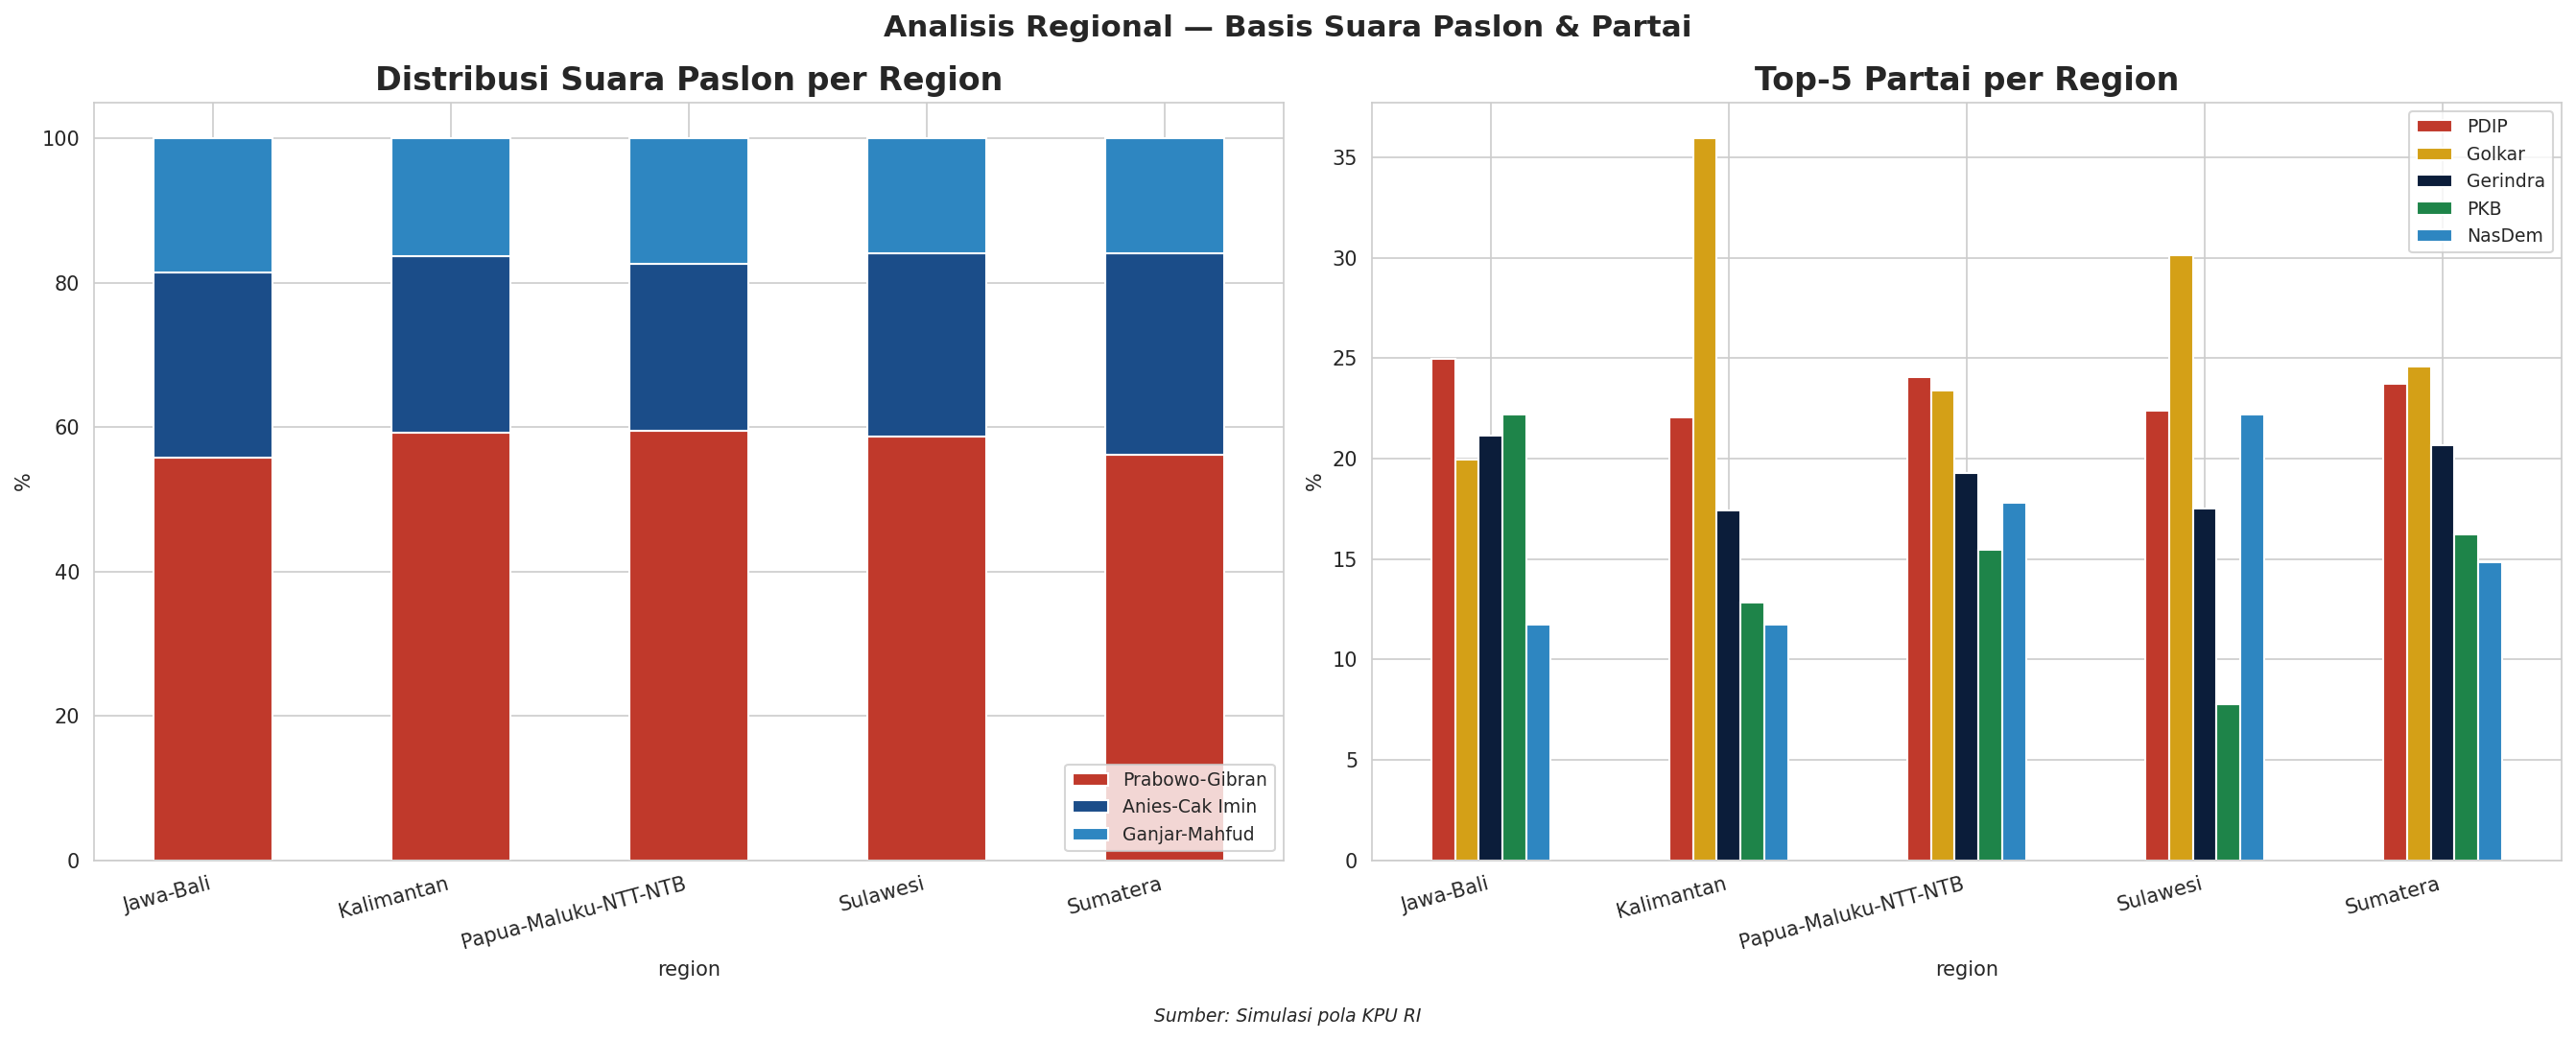


Insight regional:
  Jawa-Bali                 - unggul: Prabowo-Gibran (55.8%)
  Kalimantan                - unggul: Prabowo-Gibran (59.2%)
  Papua-Maluku-NTT-NTB      - unggul: Prabowo-Gibran (59.4%)
  Sulawesi                  - unggul: Prabowo-Gibran (58.7%)
  Sumatera                  - unggul: Prabowo-Gibran (56.2%)


In [15]:
prov_region = df_demo[['provinsi','region']].copy()
pilpres_reg = df_pilpres.merge(prov_region, on='provinsi')
partai_reg  = df_partai.merge(prov_region, on='provinsi')

# suara paslon per region
pil_r = pilpres_reg.groupby(['region','paslon'])['jumlah_suara'].sum().unstack()
pil_r_pct = pil_r.div(pil_r.sum(axis=1), axis=0) * 100

# suara partai per region (top 5)
top5 = pct_partai.head(5).index.tolist()
par_r = (partai_reg[partai_reg['partai'].isin(top5)]
         .groupby(['region','partai'])['jumlah_suara'].sum().unstack())
par_r_pct = par_r.div(par_r.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
pil_r_pct[['Prabowo-Gibran','Anies-Cak Imin','Ganjar-Mahfud']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=[WARNA_PASLON[p] for p in ['Prabowo-Gibran','Anies-Cak Imin','Ganjar-Mahfud']])
axes[0].set_title('Distribusi Suara Paslon per Region'); axes[0].set_ylabel('%')
axes[0].legend(loc='lower right', fontsize=9); axes[0].set_xticklabels(pil_r_pct.index, rotation=15, ha='right')

par_r_pct[top5].plot(kind='bar', ax=axes[1], color=[WARNA['merah'],WARNA['emas'],WARNA['navy'],WARNA['hijau'],WARNA['biru']])
axes[1].set_title('Top-5 Partai per Region'); axes[1].set_ylabel('%')
axes[1].legend(loc='upper right', fontsize=9); axes[1].set_xticklabels(par_r_pct.index, rotation=15, ha='right')

plt.suptitle('Analisis Regional — Basis Suara Paslon & Partai', fontsize=15, fontweight='bold')
plt.figtext(0.5, -0.02, 'Sumber: Simulasi pola KPU RI', ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()

print('\nInsight regional:')
for r in pil_r_pct.index:
    top = pil_r_pct.loc[r].idxmax()
    print(f'  {r:25s} - unggul: {top} ({pil_r_pct.loc[r, top]:.1f}%)')


## 15. Battleground vs Safe Seat — Selisih Pilpres per Provinsi

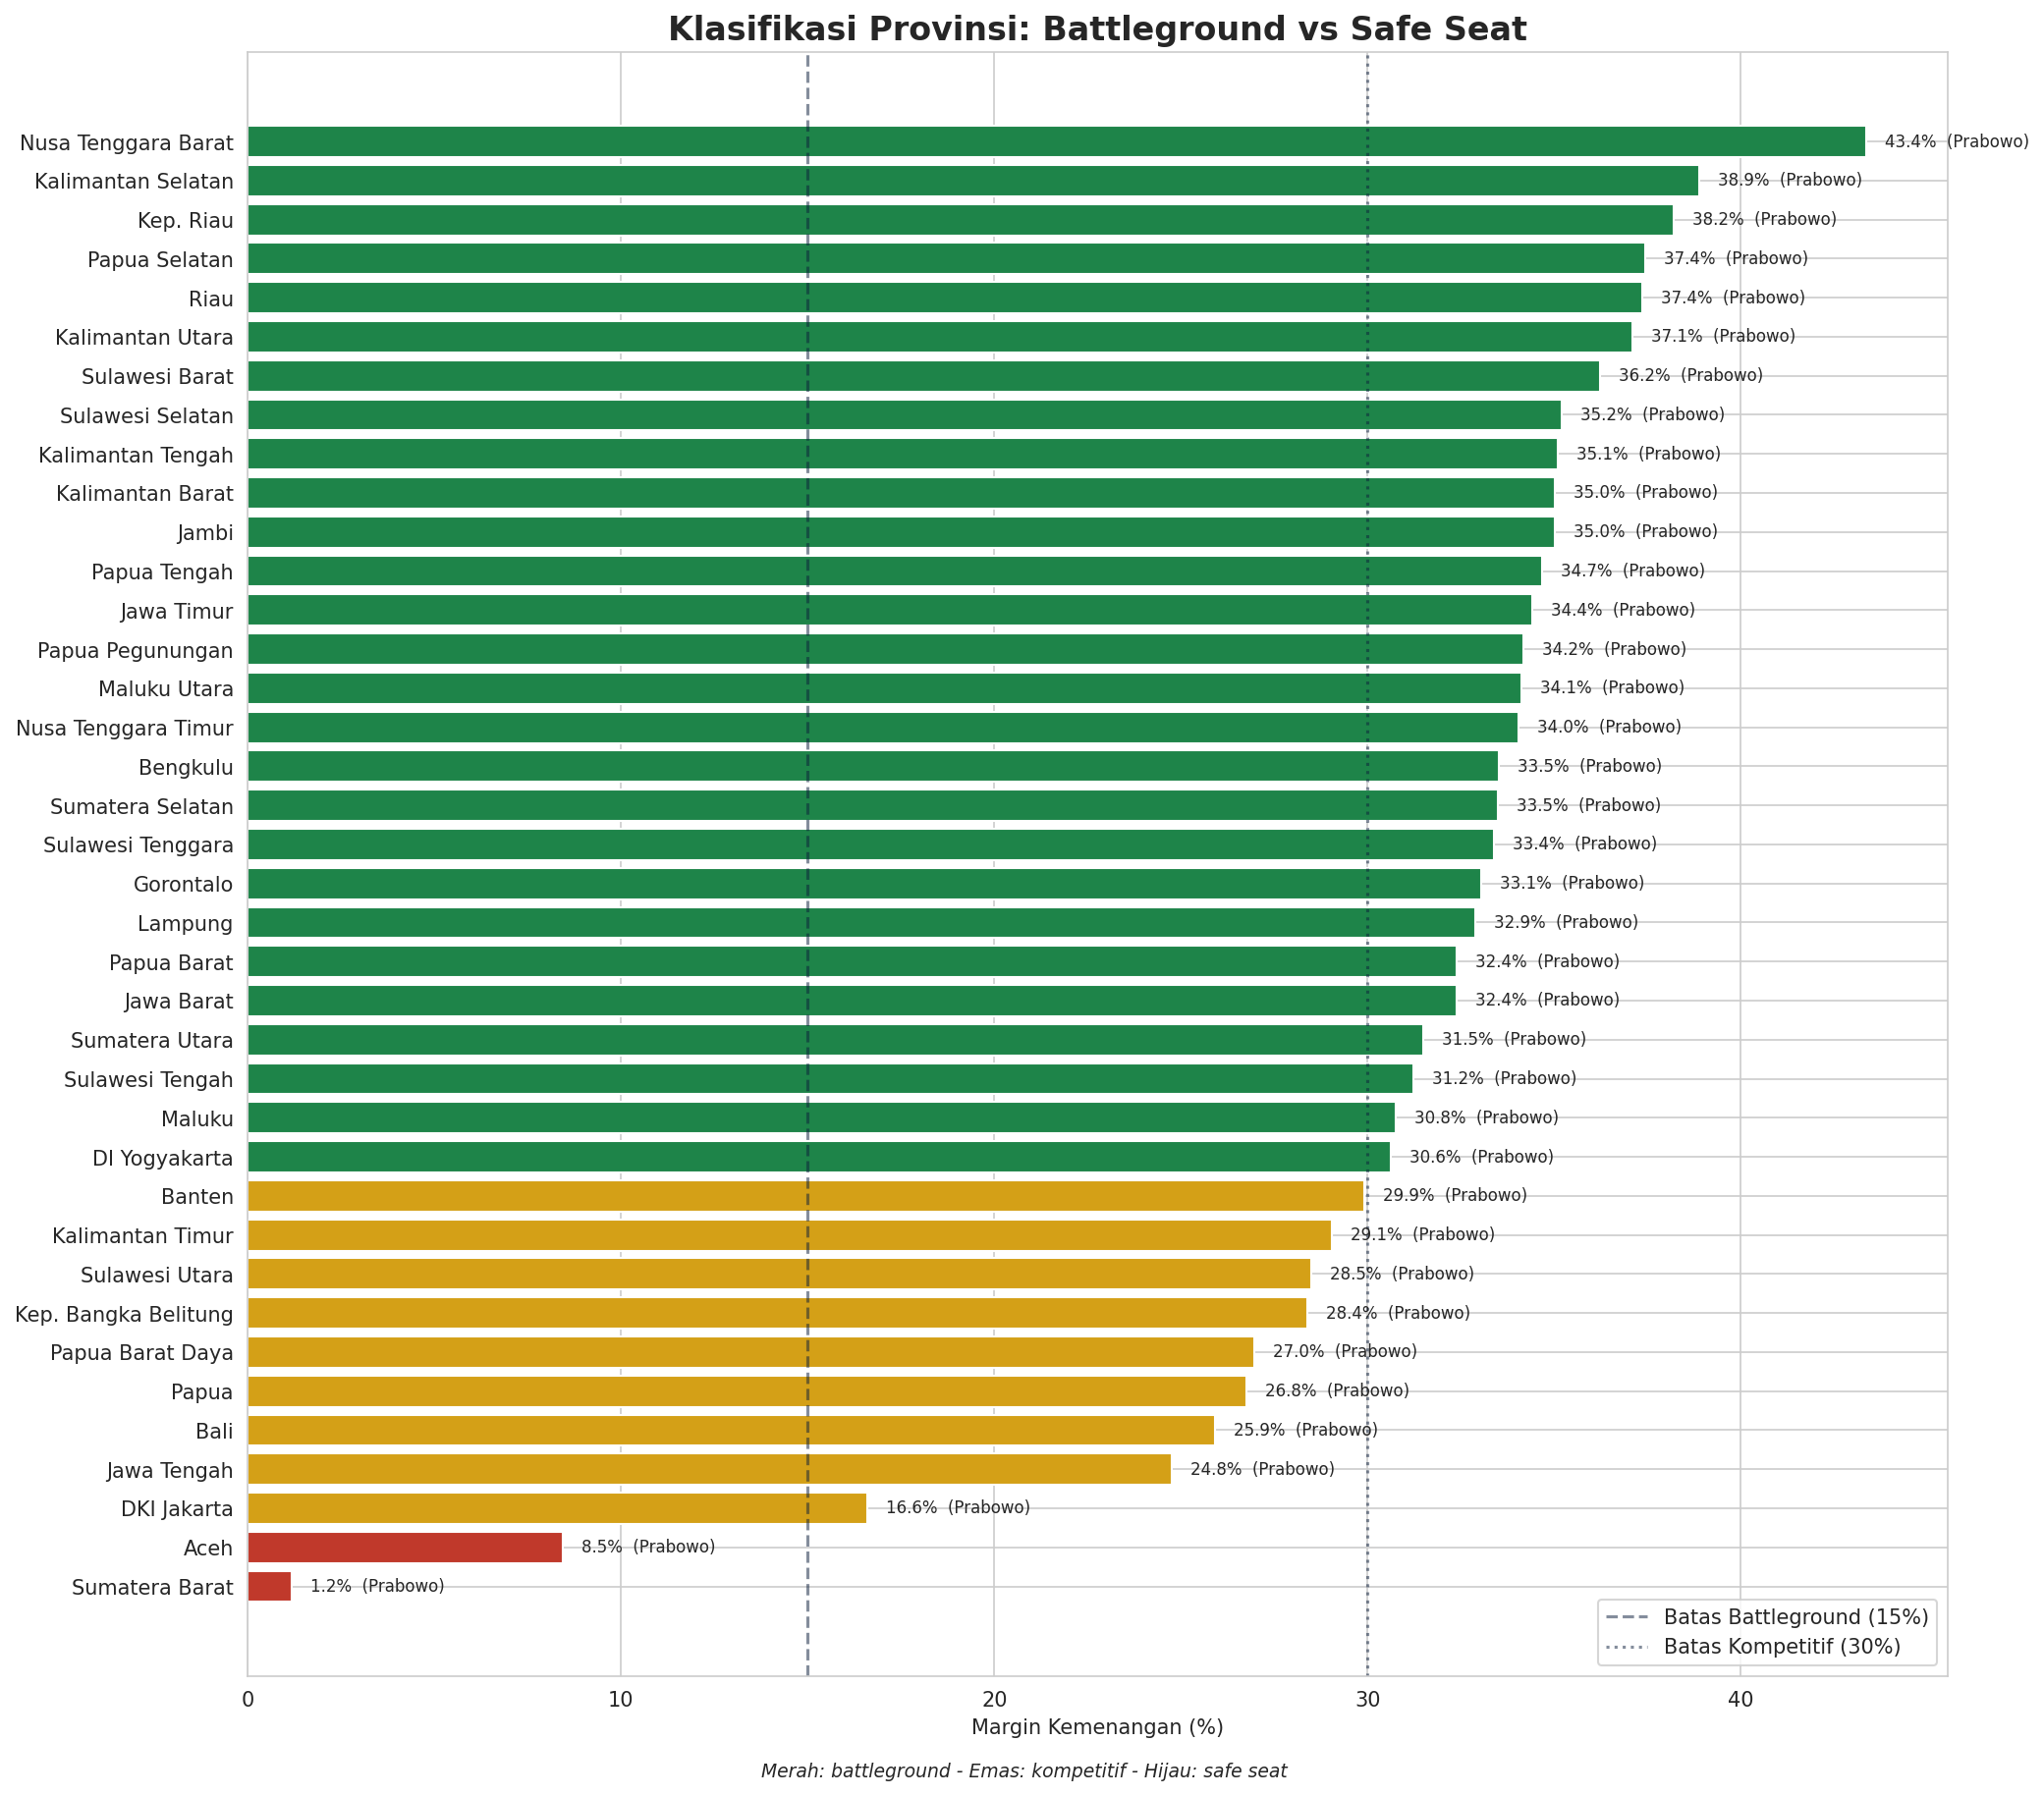


Distribusi kategori provinsi:
kategori
Safe Seat       27
Kompetitif       9
Battleground     2
Name: count, dtype: int64

Battleground provinces:
paslon                pemenang       runner_up  margin
provinsi                                              
Sumatera Barat  Prabowo-Gibran  Anies-Cak Imin    1.17
Aceh            Prabowo-Gibran  Anies-Cak Imin    8.45


In [16]:
pil_prov = df_pilpres.pivot(index='provinsi', columns='paslon', values='persentase_suara')
pil_prov['pemenang'] = pil_prov.idxmax(axis=1)
pil_prov['runner_up'] = pil_prov[['Prabowo-Gibran','Anies-Cak Imin','Ganjar-Mahfud']].apply(
    lambda r: r.drop(r.idxmax()).idxmax(), axis=1)
pil_prov['margin'] = pil_prov.apply(
    lambda r: r[r['pemenang']] - r[r['runner_up']], axis=1)
pil_prov = pil_prov.sort_values('margin')

# klasifikasi
def kategori(m):
    if m < 15: return 'Battleground'
    if m < 30: return 'Kompetitif'
    return 'Safe Seat'
pil_prov['kategori'] = pil_prov['margin'].apply(kategori)

warna_kat = {'Battleground':WARNA['merah'], 'Kompetitif':WARNA['emas'], 'Safe Seat':WARNA['hijau']}
fig, ax = plt.subplots(figsize=(14, 12))
warna_bar = [warna_kat[k] for k in pil_prov['kategori']]
ax.barh(pil_prov.index, pil_prov['margin'], color=warna_bar, edgecolor='white')
ax.axvline(15, color=WARNA['navy'], linestyle='--', alpha=0.5, label='Batas Battleground (15%)')
ax.axvline(30, color=WARNA['navy'], linestyle=':', alpha=0.5, label='Batas Kompetitif (30%)')
for i, (_, row) in enumerate(pil_prov.iterrows()):
    ax.text(row['margin']+0.5, i, f"{row['margin']:.1f}%  ({row['pemenang'].split('-')[0]})",
            va='center', fontsize=8)
ax.set_xlabel('Margin Kemenangan (%)')
ax.set_title('Klasifikasi Provinsi: Battleground vs Safe Seat')
ax.legend(loc='lower right')
plt.figtext(0.5, -0.01, 'Merah: battleground - Emas: kompetitif - Hijau: safe seat',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()

print('\nDistribusi kategori provinsi:')
print(pil_prov['kategori'].value_counts())
print('\nBattleground provinces:')
print(pil_prov[pil_prov['kategori']=='Battleground'][['pemenang','runner_up','margin']].to_string())


## 16. Cluster Profile Deep Dive — Karakter tiap Segmen

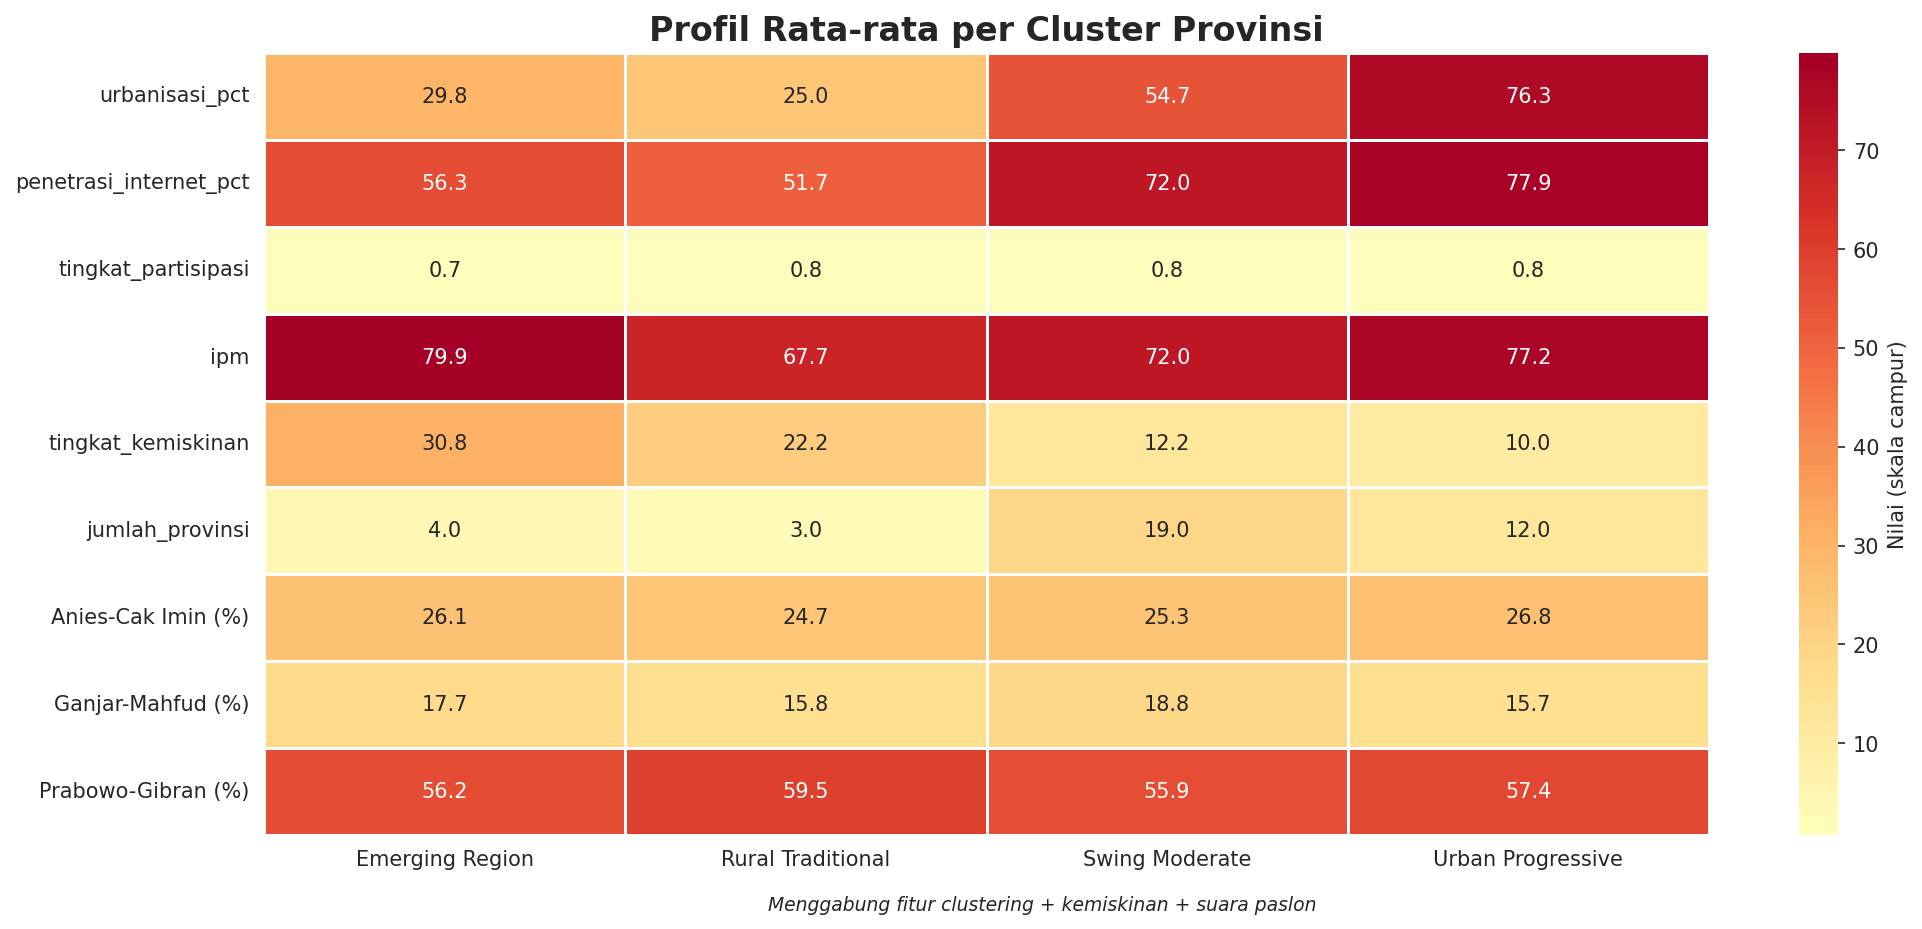

,urbanisasi_pct,penetrasi_internet_pct,tingkat_partisipasi,ipm,tingkat_kemiskinan,jumlah_provinsi,Anies-Cak Imin (%),Ganjar-Mahfud (%),Prabowo-Gibran (%)
cluster_nama,,,,,,,,,
Emerging Region,29.80,56.30,0.71,79.86,30.75,4,26.1,17.7,56.2
Rural Traditional,24.97,51.67,0.76,67.65,22.22,3,24.7,15.8,59.5
Swing Moderate,54.69,71.97,0.83,72.04,12.21,19,25.3,18.8,55.9
Urban Progressive,76.28,77.87,0.82,77.17,10.01,12,26.8,15.7,57.4


In [17]:
profil_asli = df_demo.groupby('cluster_nama')[fitur_cluster + ['tingkat_kemiskinan']].mean().round(2)
profil_asli['jumlah_provinsi'] = df_demo['cluster_nama'].value_counts()
# tambah suara Prabowo per cluster
pil_cluster = df_pilpres.merge(df_demo[['provinsi','cluster_nama']], on='provinsi')
pil_cluster_pct = (pil_cluster.groupby(['cluster_nama','paslon'])['jumlah_suara'].sum().unstack())
pil_cluster_pct = pil_cluster_pct.div(pil_cluster_pct.sum(axis=1), axis=0) * 100
profil_asli = profil_asli.join(pil_cluster_pct.round(1).add_suffix(' (%)'))

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(profil_asli.T, annot=True, fmt='.1f', cmap='RdYlBu_r', center=0,
            cbar_kws={'label':'Nilai (skala campur)'}, ax=ax, linewidths=0.5)
ax.set_title('Profil Rata-rata per Cluster Provinsi')
ax.set_xlabel(''); ax.set_ylabel('')
plt.figtext(0.5, -0.02, 'Menggabung fitur clustering + kemiskinan + suara paslon',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()
profil_asli


## 17. Simulasi Kursi DPR — Metode Sainte-Lague (Sederhana)

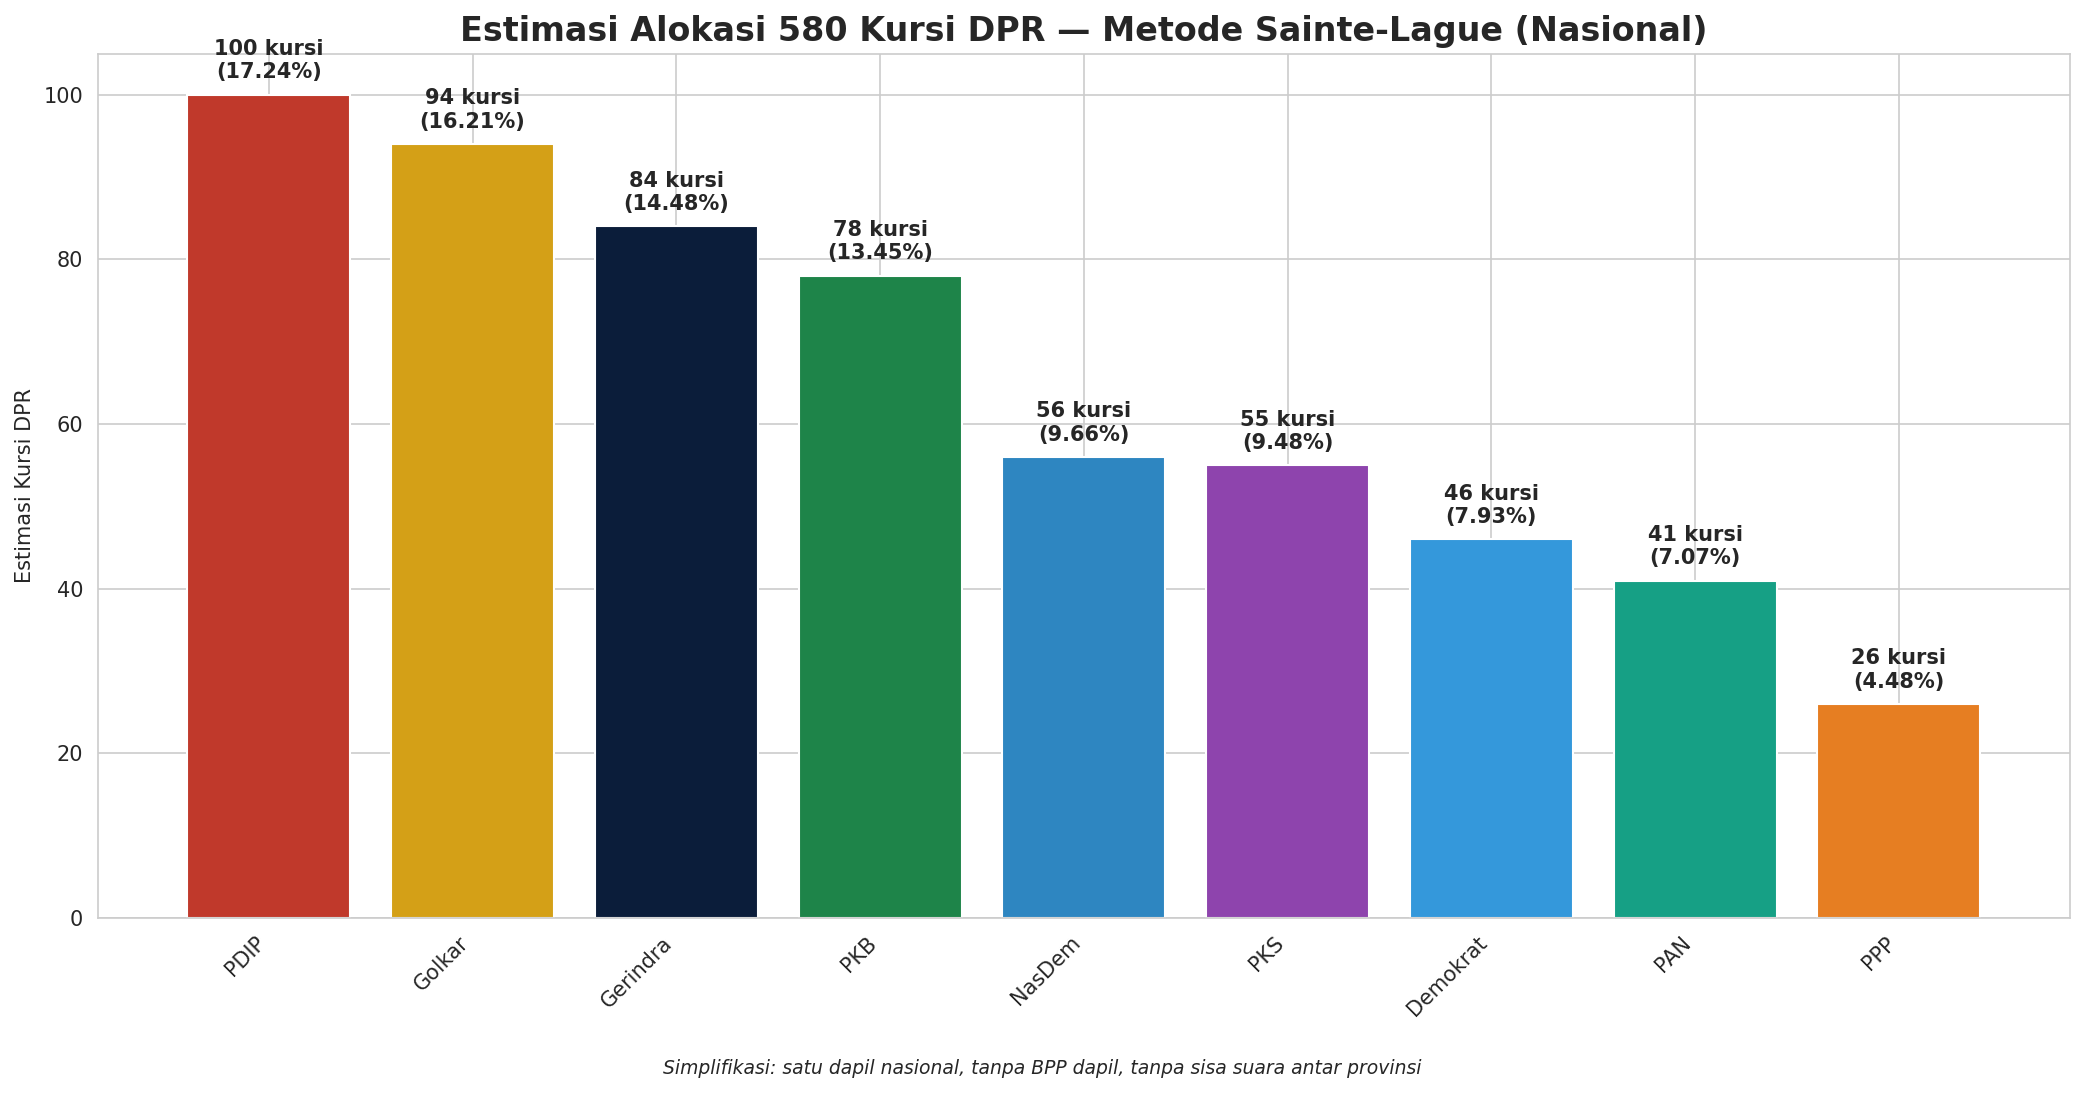

,partai,suara,kursi_estimasi,persen_kursi,persen_suara
5,PDIP,27799581,100,17.24,17.21
2,Golkar,26159633,94,16.21,16.20
1,Gerindra,23416483,84,14.48,14.50
6,PKB,21617657,78,13.45,13.38
3,NasDem,15516302,56,9.66,9.61
7,PKS,15439165,55,9.48,9.56
0,Demokrat,12950957,46,7.93,8.02
4,PAN,11305535,41,7.07,7.00
8,PPP,7311771,26,4.48,4.53


In [18]:
# metode Sainte-Lague ala Indonesia (divisor 1,3,5,7,...) diaplikasikan pada suara nasional
# dengan asumsi 580 kursi nasional (proxi total kursi DPR RI 2024)
KURSI = 580
kandidat = pct_partai[pct_partai >= 4.0]  # hanya partai lolos threshold
suara_lolos = df_partai[df_partai['partai'].isin(kandidat.index)] \
                .groupby('partai')['jumlah_suara'].sum()

# Sainte-Lague nasional (simplifikasi tanpa dapil)
kursi = {p: 0 for p in suara_lolos.index}
for _ in range(KURSI):
    quotients = {p: v / (2*kursi[p] + 1) for p, v in suara_lolos.items()}
    win = max(quotients, key=quotients.get)
    kursi[win] += 1

kursi_df = pd.DataFrame({
    'partai': list(kursi.keys()),
    'suara': [suara_lolos[p] for p in kursi],
    'kursi_estimasi': list(kursi.values()),
}).sort_values('kursi_estimasi', ascending=False)
kursi_df['persen_kursi'] = (kursi_df['kursi_estimasi'] / KURSI * 100).round(2)
kursi_df['persen_suara'] = (kursi_df['suara'] / kursi_df['suara'].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(14, 7))
warna_map = {'PDIP':WARNA['merah'], 'Gerindra':WARNA['navy'], 'Golkar':WARNA['emas'],
             'PKB':WARNA['hijau'], 'NasDem':WARNA['biru'], 'PKS':'#8E44AD',
             'Demokrat':'#3498DB', 'PAN':'#16A085', 'PPP':'#E67E22'}
warna_bar = [warna_map.get(p, WARNA['abu']) for p in kursi_df['partai']]
bars = ax.bar(kursi_df['partai'], kursi_df['kursi_estimasi'], color=warna_bar, edgecolor='white')
for bar, k, pct in zip(bars, kursi_df['kursi_estimasi'], kursi_df['persen_kursi']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
            f'{k} kursi\n({pct}%)', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Estimasi Kursi DPR')
ax.set_title(f'Estimasi Alokasi {KURSI} Kursi DPR — Metode Sainte-Lague (Nasional)')
plt.xticks(rotation=45, ha='right')
plt.figtext(0.5, -0.03,
    'Simplifikasi: satu dapil nasional, tanpa BPP dapil, tanpa sisa suara antar provinsi',
    ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()
kursi_df


## 18. Skenario Koalisi & Threshold Presiden 20%

               skenario  kursi  persen  lolos_20
Gerindra + Golkar + PKB    256   44.14      True
    PDIP + PKS + NasDem    211   36.38      True
        PDIP + Gerindra    184   31.72      True
Golkar + Demokrat + PAN    181   31.21      True


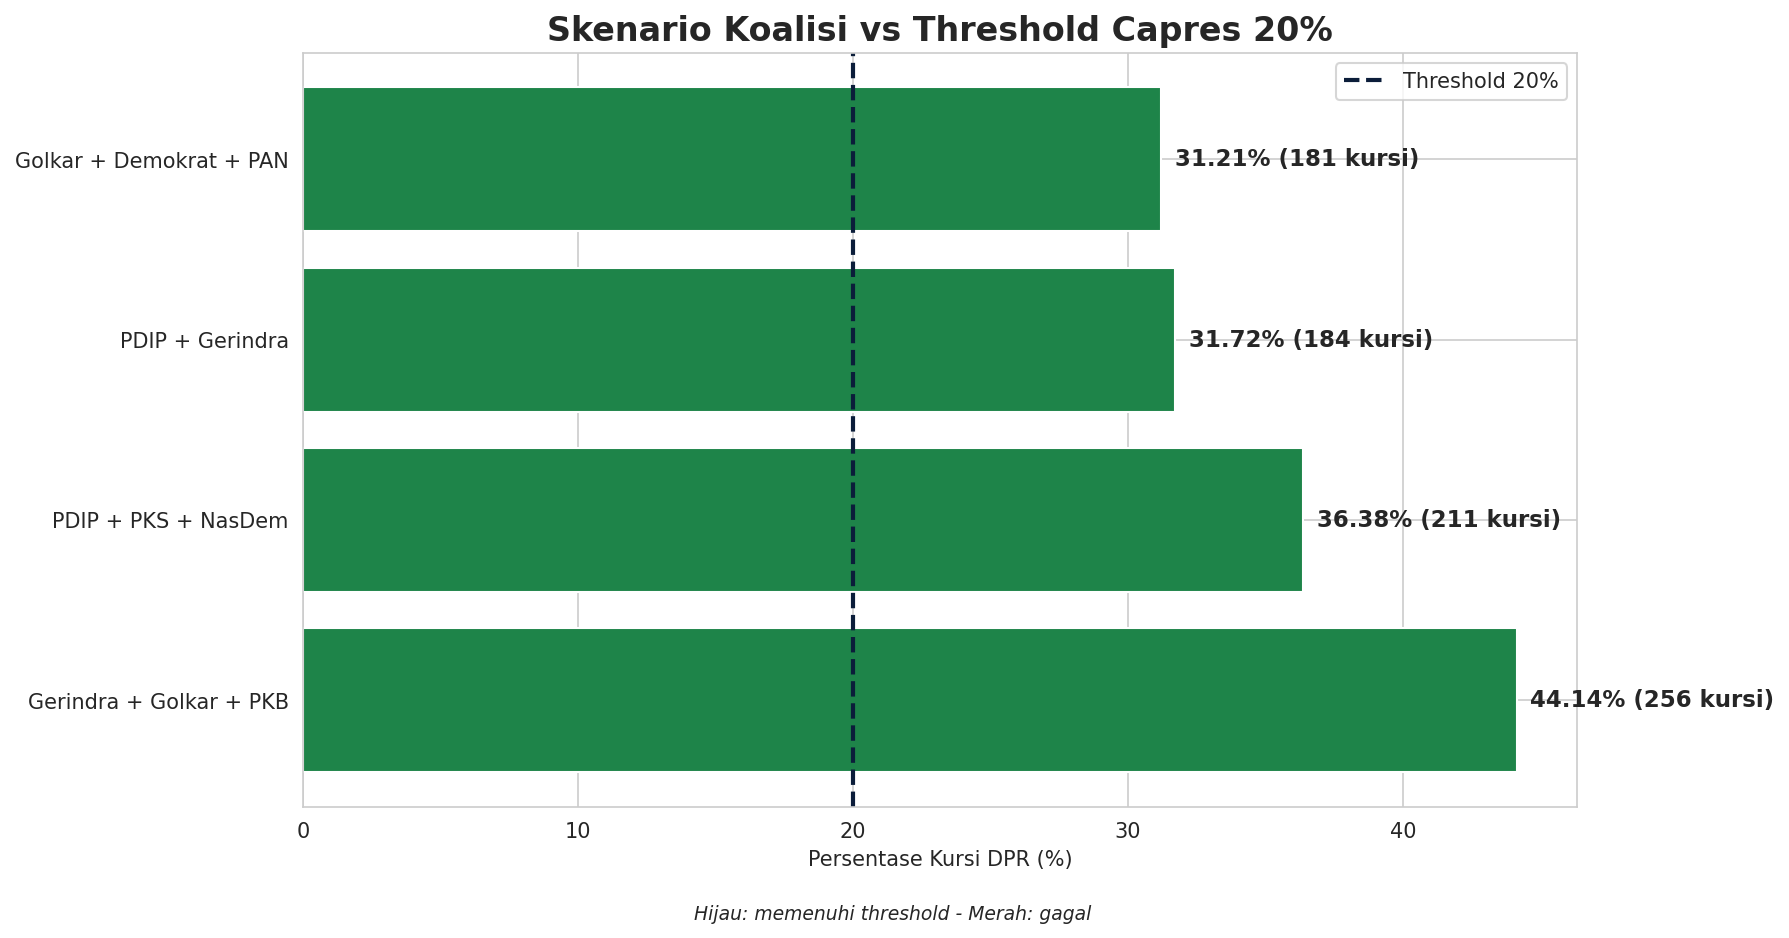

In [19]:
# Skenario koalisi minimal untuk maju sebagai capres (asumsi threshold 20% kursi DPR)
THRESHOLD = 0.20 * KURSI  # 20% kursi
kursi_map = dict(zip(kursi_df['partai'], kursi_df['kursi_estimasi']))
sorted_partai = kursi_df.sort_values('kursi_estimasi', ascending=False)

skenario = []
# skenario A: Gerindra + PKB + Golkar (koalisi pemerintahan)
# skenario B: PDIP + PKS + NasDem (oposisi historis)
# skenario C: PDIP + Gerindra (grand coalition)
kombinasi = [
    ('Gerindra + Golkar + PKB', ['Gerindra','Golkar','PKB']),
    ('PDIP + PKS + NasDem',     ['PDIP','PKS','NasDem']),
    ('PDIP + Gerindra',         ['PDIP','Gerindra']),
    ('Golkar + Demokrat + PAN', ['Golkar','Demokrat','PAN']),
]
for nama, anggota in kombinasi:
    k = sum(kursi_map.get(p,0) for p in anggota)
    skenario.append({'skenario': nama, 'kursi': k, 'persen': round(k/KURSI*100,2),
                     'lolos_20': k >= THRESHOLD})
skenario_df = pd.DataFrame(skenario)
print(skenario_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
warna_sk = [WARNA['hijau'] if l else WARNA['merah'] for l in skenario_df['lolos_20']]
bars = ax.barh(skenario_df['skenario'], skenario_df['persen'], color=warna_sk, edgecolor='white')
ax.axvline(20, color=WARNA['navy'], linestyle='--', linewidth=2, label='Threshold 20%')
for bar, pct, k in zip(bars, skenario_df['persen'], skenario_df['kursi']):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'{pct}% ({k} kursi)', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Persentase Kursi DPR (%)')
ax.set_title('Skenario Koalisi vs Threshold Capres 20%')
ax.legend()
plt.figtext(0.5, -0.03, 'Hijau: memenuhi threshold - Merah: gagal',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()


## 19. Rekomendasi Strategis

Berdasarkan hasil analisis di atas, berikut rekomendasi data-driven untuk strategi partai politik:

1. **Fokus pemilih muda (Gen Z + Milenial)** — rata-rata lebih dari 50% populasi tiap provinsi. Kampanye digital, konten video pendek, dan micro-influencer wajib jadi kanal utama, khususnya di provinsi cluster *Urban Progressive*.

2. **Segmentasi strategi per cluster** — hasil K-Means menampilkan 4 segmen: *Urban Progressive* (agenda progresif & isu iklim/tech), *Rural Traditional* (tokoh lokal & program pertanian), *Swing Moderate* (isu ekonomi rumah tangga), *Emerging Region* (Papua & sekitarnya butuh program pemerataan infrastruktur).

3. **Prioritas isu dominan negatif** — sentimen menunjukkan **korupsi** dan **kenaikan harga pangan** paling negatif. Partai wajib menampilkan track-record antikorupsi konkret dan program stabilisasi harga jika ingin merebut suara skeptis.

4. **Perkuat lumbung suara PDIP–Golkar–Gerindra** — tiga partai ini menguasai 45%+ suara nasional. Koalisi harus dihitung ulang; partai menengah (PKB, NasDem, PKS) punya kantong regional kuat yang bisa jadi swing partner.

5. **Investasi kanal digital di provinsi rendah penetrasi internet** — korelasi menunjukkan penetrasi internet berhubungan positif dengan partisipasi. Provinsi Papua & Papua Tengah butuh strategi hybrid: door-to-door + radio komunitas.

6. **Pantau tren historis** — Demokrat kehilangan dua per tiga suaranya sejak 2009 sementara Gerindra tumbuh tiga kali lipat. Pola ini menandakan pemilih Indonesia semakin dinamis; brand partai harus terus disegarkan agar tidak tergeser dalam satu siklus pemilu.
